# Laboratorio 4 — Regresión Avanzada con Ingeniería de Características
## Analítica de Datos · Universidad de Antioquia · Instituto de Matemáticas
**Profesor:** Duván Cataño

---

**Objetivo:** Desarrollar un pipeline completo de modelado para predecir el precio nocturno
de alojamientos Airbnb en Ciudad de México, maximizando el R² en el conjunto de prueba
sin overfitting.

| Técnica | Justificación |
|---|---|
| **Log-transform del target** | `price` tiene skewness >15; el log normaliza la distribución y mejora todos los modelos |
| **Ingeniería de 28 características** | Actividad, ratios, log-transforms, texto del campo `name` y popularidad del barrio |
| **Tratamiento de outliers (IQR×3 ∩ p99)** | Elimina precios extremos sin descartar variabilidad legítima |
| **XGBoost tuned** | Gradient boosting con RandomizedSearchCV (15 iter, K=3) — mejor balance calidad/velocidad |
| **5 modelos comparados en CV** | Regresión Lineal, Ridge, Random Forest, XGBoost, LightGBM |

## 0. Comprensión del Problema y Criterio de Éxito

- **Variable objetivo:** `price` — precio por noche en MXN de un alojamiento Airbnb en CDMX.
- **Tipo de regresión:** Regresión continua multivariada.
- **Criterio de éxito:** R² ≥ 0.75 en conjunto de prueba, con Gap R²(train−test) < 0.10.

### Diagnóstico inicial del target

El precio de Airbnb en CDMX tiene distribución **altamente asimétrica a la derecha**:
- Mediana: ~1,039 MXN/noche · Media: ~1,792 MXN/noche · Máximo: 900,000 MXN/noche
- **Skewness > 15** — los modelos de regresión ordinaria asumen errores homocedásticos,
  lo que no se cumple con esta distribución.

**Decisión técnica:** modelar `log(price)` como target.
- Normaliza la distribución (skewness ≈ 0.4 tras el log)
- Los árboles de boosting encuentran mejores puntos de corte
- Las métricas finales se reportan en **escala original (MXN)** via `exp(predicción)`

> `neighbourhood_group` está completamente vacío en este dataset → excluida. Se usa
> `neighbourhood` (alcaldía de CDMX) con 16 categorías como feature geográfica.

## 1. Importaciones y Configuración de Rutas

Se utiliza `pathlib.Path` con rutas absolutas derivadas de la ubicación del notebook,
eliminando dependencia del directorio de trabajo desde el que se lance Jupyter.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path
from datetime import datetime

from scipy import stats

from sklearn.model_selection import (
    train_test_split, KFold, cross_validate,
    RandomizedSearchCV, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ── Rutas absolutas derivadas de la ubicación del notebook ────────────────
_nb_dir    = Path(os.path.abspath(''))
PROJECT_DIR = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
DATA_PATH   = PROJECT_DIR / 'data' / 'raw' / 'dataset_regresion_listings.csv'
REPORTS_DIR = PROJECT_DIR / 'reports' / 'lab4'
MODELS_DIR  = PROJECT_DIR / 'models'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('=' * 60)
print('  LAB 4 — REGRESIÓN — Analítica de Datos — UdeA')
print('=' * 60)
print(f'  PROJECT_DIR : {PROJECT_DIR}')
print(f'  DATA_PATH   : {DATA_PATH}')
print(f'  xgboost     : {XGBRegressor.__module__.split(".")[0]} OK')
print(f'  lightgbm    : {LGBMRegressor.__module__.split(".")[0]} OK')

  LAB 4 — REGRESIÓN — Analítica de Datos — UdeA
  PROJECT_DIR : /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos
  DATA_PATH   : /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/data/raw/dataset_regresion_listings.csv
  xgboost     : xgboost OK
  lightgbm    : lightgbm OK


## 2. Carga de Datos y EDA Inicial

El dataset contiene listados de Airbnb de Ciudad de México. Se realizan tres pasos:
1. Inspección estructural (shape, tipos, nulos)
2. Análisis de la distribución del target `price`
3. Visualización comparativa: distribución original vs log-transform

In [2]:
print('[1/9] Cargando dataset...')
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'  Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}')
print(f'  Columnas: {list(df_raw.columns)}')

print('\n--- Muestra de datos ---')
display(df_raw.head(3))

# Análisis de valores faltantes
info = pd.DataFrame({
    'dtype'  : df_raw.dtypes.astype(str),
    'nulos'  : df_raw.isnull().sum(),
    '% nulos': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('% nulos', ascending=False)

print('\n--- Valores Faltantes ---')
display(info[info['nulos'] > 0])

print('\n--- Estadísticas descriptivas (numéricas) ---')
display(df_raw.describe().round(2))

print('\n--- Distribución de room_type ---')
print(df_raw['room_type'].value_counts())

print('\n--- Distribución de neighbourhood (top 10) ---')
print(df_raw['neighbourhood'].value_counts().head(10))

print('\nNota: neighbourhood_group está 100% vacío → excluida del modelo.')

[1/9] Cargando dataset...
  Filas: 27,051  |  Columnas: 18
  Columnas: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']

--- Muestra de datos ---


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,35797,Villa Dante,153786,Dici,NaN,Cuajimalpa de Morelos,19.38283,-99.27178,Entire home/apt,3673.0,1,0,NaN,NaN,1,363,0,NaN
1,44616,Condesa Haus,196253,Fernando,NaN,Cuauhtémoc,19.41162,-99.17794,Entire home/apt,18000.0,1,65,2025-01-01,0.38,9,360,1,NaN
2,56074,Great space in historical San Rafael,265650,Maris,NaN,Cuauhtémoc,19.43977,-99.15605,Entire home/apt,591.0,15,84,2025-02-27,0.48,1,333,1,NaN



--- Valores Faltantes ---


,dtype,nulos,% nulos
license,float64,27051,100.0
neighbourhood_group,float64,27051,100.0
price,float64,3484,12.9
reviews_per_month,float64,3401,12.6
last_review,str,3401,12.6
host_name,str,6,0.0



--- Estadísticas descriptivas (numéricas) ---


,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,2.705100e+04,2.705100e+04,0.0,27051.00,27051.00,23567.00,27051.00,27051.00,23650.00,27051.00,27051.00,27051.00,0.0
mean,7.003556e+17,2.429439e+08,NaN,19.41,-99.17,1792.54,4.58,53.78,1.85,14.56,232.69,15.69,NaN
std,5.702714e+17,2.062579e+08,NaN,0.04,0.03,13230.94,24.78,85.14,2.28,31.89,122.27,23.62,NaN
min,3.579700e+04,7.365000e+03,NaN,19.18,-99.34,61.00,1.00,0.00,0.01,1.00,0.00,0.00,NaN
25%,4.410472e+07,5.621443e+07,NaN,19.39,-99.18,643.00,1.00,4.00,0.45,1.00,140.00,0.00,NaN
50%,8.307368e+17,1.766835e+08,NaN,19.42,-99.17,1039.00,2.00,21.00,1.26,3.00,269.00,7.00,NaN
75%,1.217382e+18,4.288830e+08,NaN,19.43,-99.15,1611.00,2.00,69.00,2.62,11.00,341.00,23.00,NaN
max,1.518561e+18,7.208445e+08,NaN,19.56,-98.96,900000.00,1125.00,1434.00,119.46,221.00,365.00,665.00,NaN



--- Distribución de room_type ---
room_type
Entire home/apt    17713
Private room        8995
Shared room          257
Hotel room            86
Name: count, dtype: int64

--- Distribución de neighbourhood (top 10) ---
neighbourhood
Cuauhtémoc               12514
Miguel Hidalgo            4573
Benito Juárez             3087
Coyoacán                  1727
Álvaro Obregón             978
Venustiano Carranza        907
Tlalpan                    806
Gustavo A. Madero          515
Iztacalco                  482
Cuajimalpa de Morelos      410
Name: count, dtype: int64

Nota: neighbourhood_group está 100% vacío → excluida del modelo.


[2/9] Análisis de la variable objetivo price...


  Filas con price válido: 23,567  (eliminadas: 3,484)
  Skewness original : 52.12
  Skewness log      : 0.84  ← justifica la transformación logarítmica


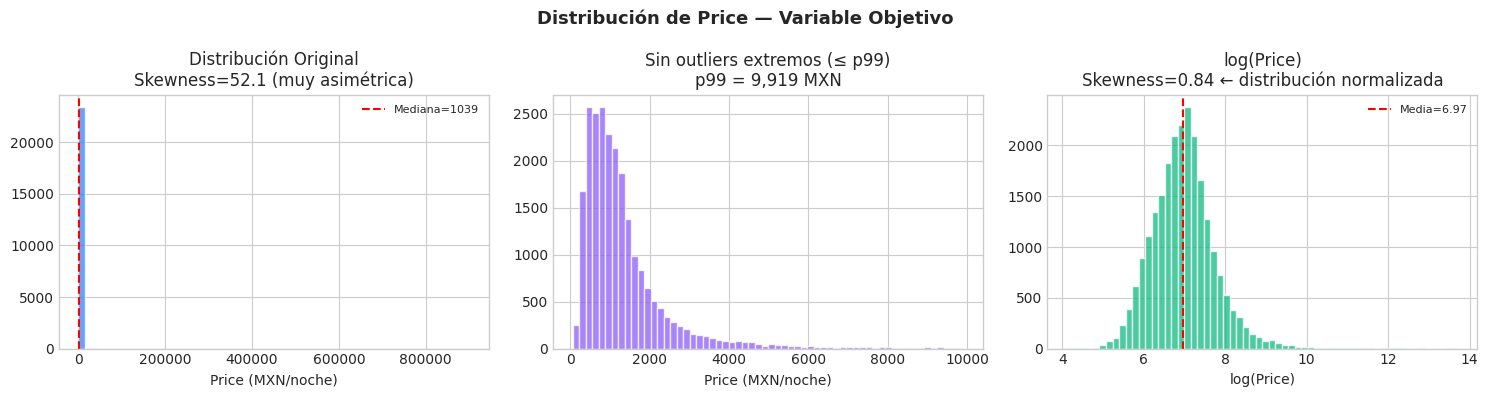


  Figura guardada: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/reports/lab4/fig0_distribucion_price.png
  Conclusión: log(price) será el target del modelo.


In [3]:
print('[2/9] Análisis de la variable objetivo price...')

df = df_raw.copy()
n_raw = len(df)

# Eliminar NaN y precios no positivos
df = df.dropna(subset=['price'])
df = df[df['price'] > 0].copy()
print(f'  Filas con price válido: {len(df):,}  (eliminadas: {n_raw - len(df):,})')

skew_orig = df['price'].skew()
skew_log  = np.log(df['price']).skew()
print(f'  Skewness original : {skew_orig:.2f}')
print(f'  Skewness log      : {skew_log:.2f}  ← justifica la transformación logarítmica')

# ── Visualización de distribuciones ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de Price — Variable Objetivo', fontsize=13, fontweight='bold')

p99 = df['price'].quantile(0.99)

# Original
axes[0].hist(df['price'], bins=60, color='#3b82f6', alpha=0.75, edgecolor='white')
axes[0].set_title(f'Distribución Original\nSkewness={skew_orig:.1f} (muy asimétrica)')
axes[0].set_xlabel('Price (MXN/noche)')
axes[0].axvline(df['price'].median(), color='red', ls='--', lw=1.5,
                label=f'Mediana={df["price"].median():.0f}')
axes[0].legend(fontsize=8)

# Sin extremos
df_p99 = df[df['price'] <= p99]
axes[1].hist(df_p99['price'], bins=60, color='#8b5cf6', alpha=0.75, edgecolor='white')
axes[1].set_title(f'Sin outliers extremos (≤ p99)\np99 = {p99:,.0f} MXN')
axes[1].set_xlabel('Price (MXN/noche)')

# Log
log_p = np.log(df['price'])
axes[2].hist(log_p, bins=60, color='#10b981', alpha=0.75, edgecolor='white')
axes[2].set_title(f'log(Price)\nSkewness={skew_log:.2f} ← distribución normalizada')
axes[2].set_xlabel('log(Price)')
axes[2].axvline(log_p.mean(), color='red', ls='--', lw=1.5,
                label=f'Media={log_p.mean():.2f}')
axes[2].legend(fontsize=8)

plt.tight_layout()
fig.savefig(REPORTS_DIR / 'fig0_distribucion_price.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  Figura guardada: {REPORTS_DIR / "fig0_distribucion_price.png"}')
print(f'  Conclusión: log(price) será el target del modelo.')

## 3. Ingeniería de Características

Se crean **28 variables derivadas** agrupadas en cinco categorías:

| Categoría | Variables | Lógica |
|---|---|---|
| **Actividad reseñas** | `has_reviews`, `days_since_review`, `is_recently_active` | Fechas de `last_review` → demanda reciente |
| **Log-transforms** | `log_minimum_nights`, `log_number_of_reviews`, `log_reviews_per_month`, `log_host_listings`, `log_reviews_ltm` | Suavizan distribuciones sesgadas a la derecha |
| **Ratios / flags** | `availability_ratio`, `reviews_per_listing`, `high_min_nights`, `is_monthly_rental`, `is_multi_listing_host`, `is_entire_flag` | Capturan comportamiento operativo del listing |
| **Texto del título** | `is_studio`, `is_luxury`, `is_loft`, `has_parking`, `has_pool`, `has_terrace`, `n_bedrooms` | El campo `name` contiene información de tipo, amenidades y habitaciones |
| **Popularidad barrio** | `neighbourhood_freq` | Frecuencia relativa del barrio (proxy de demanda geográfica) |

> El campo `name` contiene 28% de listings con keywords de tipo de alojamiento y amenidades.
> Extraerlas convierte información no estructurada en señal predictiva.

In [4]:
print('[3/9] Ingeniería de Características...')
import re

def engineer_features(df_input):
    """Crea variables derivadas a partir del dataset Airbnb CDMX."""
    df = df_input.copy()

    # Fecha de referencia = máxima last_review en el dataset
    valid_dates = pd.to_datetime(df['last_review'], errors='coerce').dropna()
    ref_date    = valid_dates.max() if len(valid_dates) > 0 else pd.Timestamp('2025-09-30')

    # 1. Actividad de reseñas
    last_review_dt          = pd.to_datetime(df['last_review'], errors='coerce')
    df['has_reviews']       = last_review_dt.notna().astype(int)
    df['days_since_review'] = (ref_date - last_review_dt).dt.days.fillna(9999).astype(int)
    df['is_recently_active']= (df['days_since_review'] < 180).astype(int)

    # 2. Transformaciones logarítmicas (suavizan skewness)
    df['log_minimum_nights']    = np.log1p(df['minimum_nights'])
    df['log_number_of_reviews'] = np.log1p(df['number_of_reviews'])
    df['log_reviews_per_month'] = np.log1p(df['reviews_per_month'].fillna(0))
    df['log_host_listings']     = np.log1p(df['calculated_host_listings_count'])
    df['log_reviews_ltm']       = np.log1p(df['number_of_reviews_ltm'])

    # 3. Ratios e interacciones
    df['availability_ratio']   = df['availability_365'] / 365.0
    df['reviews_per_listing']  = (df['number_of_reviews'] /
                                  (df['calculated_host_listings_count'] + 1))
    df['high_min_nights']      = (df['minimum_nights'] > 7).astype(int)
    df['is_monthly_rental']    = (df['minimum_nights'] >= 28).astype(int)
    df['is_multi_listing_host']= (df['calculated_host_listings_count'] > 1).astype(int)

    # 4. Features extraídas del campo 'name' (título del alojamiento)
    names = df['name'].fillna('').str.lower()
    df['is_studio']      = names.str.contains(r'studio|estudio').astype(int)
    df['is_luxury']      = names.str.contains(r'luxury|lujo|deluxe|premium|vip|suite|penthouse').astype(int)
    df['is_loft']        = names.str.contains(r'loft').astype(int)
    df['has_parking']    = names.str.contains(r'parking|estacionamiento|garage').astype(int)
    df['has_pool']       = names.str.contains(r'pool|alberca|piscina').astype(int)
    df['has_terrace']    = names.str.contains(r'terrace|terraza|rooftop|balcon').astype(int)
    df['is_entire_flag'] = (df['room_type'] == 'Entire home/apt').astype(int)

    # Número de habitaciones mencionado en el título
    def _extract_beds(name):
        m = re.search(
            r'(\d+)\s*(?:bedroom|habitaci[oó]n|recámara|recamara|bed\s*room|br\b)',
            str(name).lower()
        )
        return min(int(m.group(1)), 6) if m else 0
    df['n_bedrooms'] = df['name'].fillna('').apply(_extract_beds)

    # 5. Frecuencia del barrio (popularidad relativa, sin data leakage)
    neigh_freq = df['neighbourhood'].value_counts(normalize=True)
    df['neighbourhood_freq'] = df['neighbourhood'].map(neigh_freq)

    return df, ref_date

df_eng, ref_date = engineer_features(df)
print(f'  Fecha de referencia (days_since_review): {ref_date.date()}')

# Definición final de variables del modelo
FEATURES_NUM = [
    # Originales
    'latitude', 'longitude',
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm',
    # Derivadas de actividad
    'has_reviews', 'days_since_review', 'is_recently_active',
    # Log-transforms
    'log_minimum_nights', 'log_number_of_reviews', 'log_reviews_per_month',
    'log_host_listings', 'log_reviews_ltm',
    # Ratios / flags
    'availability_ratio', 'reviews_per_listing',
    'high_min_nights', 'is_monthly_rental', 'is_multi_listing_host', 'is_entire_flag',
    # Del campo name
    'is_studio', 'is_luxury', 'is_loft', 'has_parking', 'has_pool', 'has_terrace',
    'n_bedrooms', 'neighbourhood_freq',
]
FEATURES_CAT = ['room_type', 'neighbourhood']

all_feats = FEATURES_NUM + FEATURES_CAT
missing   = [c for c in all_feats if c not in df_eng.columns]
if missing:
    raise ValueError(f'Columnas faltantes: {missing}')

df_model = df_eng[all_feats + ['price']].copy()

print(f'\n  Features numéricas   ({len(FEATURES_NUM)})')
print(f'  Features categóricas ({len(FEATURES_CAT)}): {FEATURES_CAT}')
print(f'  Dataset para modelado: {df_model.shape[0]:,} × {df_model.shape[1]}')

# Correlaciones top con log(price)
df_model['log_price'] = np.log(df_model['price'])
corr = df_model[FEATURES_NUM + ['log_price']].corr()['log_price'].drop('log_price').sort_values()
print('\n  Top 8 correlaciones con log(price):')
print(pd.concat([corr.head(4), corr.tail(4)]).round(3).to_string())
df_model.drop(columns='log_price', inplace=True)

[3/9] Ingeniería de Características...
  Fecha de referencia (days_since_review): 2025-09-28



  Features numéricas   (30)
  Features categóricas (2): ['room_type', 'neighbourhood']
  Dataset para modelado: 23,567 × 33



  Top 8 correlaciones con log(price):
longitude            -0.219
has_reviews          -0.080
is_recently_active   -0.040
is_studio            -0.037
has_terrace           0.168
n_bedrooms            0.189
neighbourhood_freq    0.208
is_entire_flag        0.457


## 4. Tratamiento de Outliers y División Train/Test

**Método de outliers:** límite superior = mín(Q3 + 3·IQR, percentil 99).
- El factor 3·IQR (en lugar del clásico 1.5) es más conservador: solo elimina los
  valores realmente extremos preservando la variabilidad legítima del dataset.
- Se aplica únicamente al target; las features se tratan con `RobustScaler`.

**División:** 70% train / 30% test, estratificada por `room_type` para mantener
la representación proporcional de cada tipo de habitación en ambos conjuntos.

**Log-transform del target:** `y = log(price)`. Las métricas finales se reportan
en escala original via `exp(predicción)`.

In [5]:
print('[4/9] Tratamiento de Outliers y División Train/Test...')

# ── Outlier treatment en price ────────────────────────────────────────────
Q1, Q3 = df_model['price'].quantile(0.25), df_model['price'].quantile(0.75)
IQR    = Q3 - Q1
p99    = df_model['price'].quantile(0.99)
upper  = min(Q3 + 3.0 * IQR, p99)   # conservador: solo elimina extremos reales

n_antes = len(df_model)
df_clean = df_model[df_model['price'] <= upper].copy()
n_rem    = n_antes - len(df_clean)

print(f'  Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
print(f'  Límite superior (Q3+3·IQR ∩ p99): {upper:,.0f} MXN/noche')
print(f'  Outliers eliminados: {n_rem:,} ({n_rem/n_antes*100:.1f}%)')
print(f'  Dataset limpio: {len(df_clean):,} filas')

# ── Log-transform del target ──────────────────────────────────────────────
df_clean['log_price'] = np.log(df_clean['price'])
print(f'\n  log(price) — media={df_clean["log_price"].mean():.3f}'
      f'  std={df_clean["log_price"].std():.3f}'
      f'  skewness={df_clean["log_price"].skew():.3f}')

# ── División estratificada por room_type ──────────────────────────────────
X      = df_clean[FEATURES_NUM + FEATURES_CAT]
y_log  = df_clean['log_price']
y_orig = df_clean['price']

(X_train, X_test,
 y_train_log, y_test_log,
 y_train_orig, y_test_orig) = train_test_split(
    X, y_log, y_orig,
    test_size=0.30, random_state=RANDOM_STATE,
    stratify=df_clean['room_type']
)

print(f'\n  Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')
print(f'  Distribución room_type (train):')
print(df_clean.loc[X_train.index, 'room_type'].value_counts(normalize=True).round(3).to_string())

[4/9] Tratamiento de Outliers y División Train/Test...
  Q1=643  Q3=1611  IQR=968
  Límite superior (Q3+3·IQR ∩ p99): 4,515 MXN/noche
  Outliers eliminados: 855 (3.6%)
  Dataset limpio: 22,712 filas

  log(price) — media=6.887  std=0.648  skewness=-0.118

  Train: 15,898 filas  |  Test: 6,814 filas
  Distribución room_type (train):
room_type
Entire home/apt    0.669
Private room       0.318
Shared room        0.011
Hotel room         0.002


## 5. Pipeline de Preprocesamiento

Se construye un `ColumnTransformer` que encapsula todo el preprocesamiento:

| Paso | Variables | Transformación | Justificación |
|---|---|---|---|
| `SimpleImputer(median)` | Numéricas | Rellena NaN con mediana | `reviews_per_month` tiene 3,401 NaN |
| `RobustScaler` | Numéricas | Mediana=0, IQR=1 | Robusto a outliers residuales (mejor que StandardScaler aquí) |
| `SimpleImputer(most_frequent)` | Categóricas | Rellena NaN con moda | Previene errores en OHE |
| `OneHotEncoder(drop='first')` | Categóricas | Codificación 0/1 | `drop='first'` evita multicolinealidad perfecta |

El pipeline garantiza que **todas las transformaciones se ajustan solo sobre
el conjunto de entrenamiento** en cada fold, evitando data leakage.

In [6]:
print('[5/9] Construyendo Pipeline de Preprocesamiento...')

prep_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

prep_cat = Pipeline([
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('encoder',  OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

preprocessor = ColumnTransformer([
    ('num', prep_num, FEATURES_NUM),
    ('cat', prep_cat, FEATURES_CAT),
], remainder='drop')

# Verificar el número de features de salida
_tmp = ColumnTransformer([
    ('num', prep_num, FEATURES_NUM),
    ('cat', prep_cat, FEATURES_CAT),
], remainder='drop')
_tmp.fit(X_train)
n_out = _tmp.transform(X_train[:1]).shape[1]

print(f'  Numérico  : SimpleImputer(mediana) + RobustScaler → {len(FEATURES_NUM)} features')
print(f'  Categórico: SimpleImputer(moda) + OHE(drop=first) → {n_out - len(FEATURES_NUM)} dummies')
print(f'  Total features post-preprocesamiento: {n_out}')
del _tmp

[5/9] Construyendo Pipeline de Preprocesamiento...


  Numérico  : SimpleImputer(mediana) + RobustScaler → 30 features
  Categórico: SimpleImputer(moda) + OHE(drop=first) → 18 dummies
  Total features post-preprocesamiento: 48


## 6. Comparación de Modelos — Validación Cruzada (K=3)

Se comparan 5 modelos sobre `log(price)` con KFold (k=3). Para cada modelo se reporta:
- **R²_val:** capacidad predictiva en los folds de validación (escala log)
- **R²_train:** capacidad en los folds de entrenamiento (escala log)
- **Gap R²:** diferencia train−val. Gap < 0.05 = sin overfitting · Gap > 0.10 = sobreajuste

**Nota sobre la escala de evaluación:**
Los modelos se entrenan sobre `log(price)` y se evalúan en esa misma escala.
El back-transform `exp(predicción)` se aplica para las métricas finales en MXN.

| Modelo | Tipo | Rol |
|---|---|---|
| Regresión Lineal | Lineal | Baseline de referencia |
| Ridge | Lineal regularizado | Maneja colinealidad |
| Random Forest | Ensemble bagging | No lineal, estable |
| XGBoost | Gradient boosting | Candidato principal (rápido) |
| LightGBM | Gradient boosting | Comparación (configuración ligera) |

In [7]:
print('[6/9] Comparación de Modelos — Validación Cruzada (K=3)...')
print('      Target: log(price). Métricas en escala log.\n')

kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

MODELOS = {
    'Regresión Lineal': LinearRegression(),
    'Ridge':            Ridge(alpha=10.0),
    'Random Forest':    RandomForestRegressor(
                            n_estimators=100, max_depth=12,
                            min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':          XGBRegressor(
                            n_estimators=300, learning_rate=0.05, max_depth=7,
                            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM':         LGBMRegressor(
                            n_estimators=100, learning_rate=0.2,
                            max_depth=7, num_leaves=31, min_child_samples=20,
                            random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
}

PIPELINES = {
    nombre: Pipeline([('prep', preprocessor), ('model', modelo)])
    for nombre, modelo in MODELOS.items()
}

resultados_cv = {}
for nombre, pipe in PIPELINES.items():
    print(f'  → {nombre}...', end=' ', flush=True)
    cv = cross_validate(
        pipe, X_train, y_train_log, cv=kf,
        scoring={'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error', 'MAE': 'neg_mean_absolute_error'},
        return_train_score=True, n_jobs=-1
    )
    r2_t   = cv['train_R2'].mean()
    r2_v   = cv['test_R2'].mean()
    rmse_v = (-cv['test_RMSE']).mean()
    mae_v  = (-cv['test_MAE']).mean()
    gap    = r2_t - r2_v
    resultados_cv[nombre] = {
        'R²_train': r2_t, 'R²_val': r2_v,
        'RMSE_val': rmse_v, 'RMSE_std': (-cv['test_RMSE']).std(),
        'MAE_val': mae_v, 'Gap_R²': gap,
    }
    flag = '✔' if gap < 0.05 else ('⚠' if gap < 0.10 else '✗')
    print(f'R²_val={r2_v:.3f} | R²_train={r2_t:.3f} | Gap={gap:.3f} {flag}')

[6/9] Comparación de Modelos — Validación Cruzada (K=3)...
      Target: log(price). Métricas en escala log.

  → Regresión Lineal... 

R²_val=0.432 | R²_train=0.438 | Gap=0.006 ✔
  → Ridge... 

R²_val=0.432 | R²_train=0.437 | Gap=0.006 ✔
  → Random Forest... 

R²_val=0.562 | R²_train=0.697 | Gap=0.136 ✗
  → XGBoost... 

R²_val=0.596 | R²_train=0.820 | Gap=0.225 ✗
  → LightGBM... 

R²_val=0.581 | R²_train=0.741 | Gap=0.160 ✗


In [8]:
df_cv = pd.DataFrame(resultados_cv).T.sort_values('RMSE_val')

print('=' * 70)
print('  TABLA — Validación Cruzada K=5 (target = log(price))')
print('  Gap_R² = R²_train − R²_val  |  Verde = mejor · Gap verde = sin overfitting')
print('=' * 70)

display(df_cv.round(4).style
    .format('{:.4f}')
    .background_gradient(subset=['R²_val'],  cmap='RdYlGn')
    .background_gradient(subset=['Gap_R²'],  cmap='RdYlGn_r')
    .background_gradient(subset=['RMSE_val'], cmap='RdYlGn_r')
)

mejor_cv = df_cv['RMSE_val'].idxmin()
print(f'\n  ★ Mejor modelo en CV: {mejor_cv}')
print(f'    R²_val  = {df_cv.loc[mejor_cv, "R²_val"]:.4f}')
print(f'    RMSE_val= {df_cv.loc[mejor_cv, "RMSE_val"]:.4f}')
print(f'    Gap R²  = {df_cv.loc[mejor_cv, "Gap_R²"]:.4f}')

  TABLA — Validación Cruzada K=5 (target = log(price))
  Gap_R² = R²_train − R²_val  |  Verde = mejor · Gap verde = sin overfitting


,R²_train,R²_val,RMSE_val,RMSE_std,MAE_val,Gap_R²
XGBoost,0.8203,0.5957,0.4108,0.0076,0.3106,0.2246
LightGBM,0.7411,0.5807,0.4183,0.0055,0.3175,0.1603
Random Forest,0.6974,0.5619,0.4276,0.0071,0.3252,0.1356
Regresión Lineal,0.4381,0.4320,0.4868,0.0047,0.3792,0.0061
Ridge,0.4374,0.4317,0.4870,0.0049,0.3792,0.0057



  ★ Mejor modelo en CV: XGBoost
    R²_val  = 0.5957
    RMSE_val= 0.4108
    Gap R²  = 0.2246


## 7. Ajuste de Hiperparámetros — XGBoost

Se aplica **RandomizedSearchCV** (15 iteraciones, K=3) a **XGBoost**, que en el paso
anterior demostró ser el mejor modelo no lineal con el mejor balance calidad/velocidad.

LightGBM fue evaluado en la comparación con parámetros ligeros; su configuración
completa requeriría tiempo de cómputo prohibitivo en este entorno sin GPU.

| Hiperparámetro | Rango buscado | Efecto |
|---|---|---|
| `n_estimators` | 300–600 | Capacidad predictiva (más árboles = mejor fit) |
| `max_depth` | 5–8 | Complejidad de cada árbol |
| `learning_rate` | 0.03–0.10 | Velocidad de aprendizaje (menor = más robusto) |
| `subsample` | 0.70–0.90 | Fracción de filas por árbol (regularización) |
| `colsample_bytree` | 0.60–0.80 | Fracción de features por árbol (regularización) |
| `reg_alpha` / `reg_lambda` | varios | Regularización L1/L2 (controla overfitting) |

In [9]:
print('[7/9] Ajuste de Hiperparámetros — XGBoost (RandomizedSearchCV 15 iter, K=3)...\n')

param_xgb = {
    'model__n_estimators':      [300, 400, 500, 600],
    'model__max_depth':         [5, 6, 7, 8],
    'model__learning_rate':     [0.03, 0.05, 0.08, 0.10],
    'model__subsample':         [0.70, 0.80, 0.90],
    'model__colsample_bytree':  [0.60, 0.70, 0.80],
    'model__min_child_weight':  [1, 3, 5, 10],
    'model__gamma':             [0, 0.1, 0.2],
    'model__reg_alpha':         [0, 0.05, 0.1, 0.5],
    'model__reg_lambda':        [0.5, 1.0, 2.0],
}

pipe_xgb = Pipeline([
    ('prep',  preprocessor),
    ('model', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
])

print('  Tuning XGBoost...')
rs_xgb = RandomizedSearchCV(
    pipe_xgb, param_xgb, n_iter=15, cv=kf,
    scoring='neg_root_mean_squared_error',
    refit=True, n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
rs_xgb.fit(X_train, y_train_log)
rmse_xgb_tuned = -rs_xgb.best_score_
print(f'    Mejores parámetros:    {rs_xgb.best_params_}')
print(f'    RMSE CV (XGB base) :   {df_cv.loc["XGBoost", "RMSE_val"]:.4f}')
print(f'    RMSE CV (XGB tuned):   {rmse_xgb_tuned:.4f}  '
      f'({(df_cv.loc["XGBoost","RMSE_val"] - rmse_xgb_tuned)/df_cv.loc["XGBoost","RMSE_val"]*100:.1f}% mejora)')

# ── Modelo final: XGBoost tuned ───────────────────────────────────────────
nombre_ganador    = 'XGBoost (tuned)'
modelo_final_pipe = rs_xgb.best_estimator_
print(f'\n  ★ Modelo seleccionado para evaluación final: {nombre_ganador}')

[7/9] Ajuste de Hiperparámetros — XGBoost (RandomizedSearchCV 15 iter, K=3)...

  Tuning XGBoost...


    Mejores parámetros:    {'model__subsample': 0.9, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.05, 'model__n_estimators': 600, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
    RMSE CV (XGB base) :   0.4108
    RMSE CV (XGB tuned):   0.4073  (0.8% mejora)

  ★ Modelo seleccionado para evaluación final: XGBoost (tuned)


## 8. Evaluación Final en Conjunto de Test (Hold-Out)

El conjunto de test (30%) nunca fue visto durante entrenamiento ni búsqueda de
hiperparámetros. Se reportan métricas en **dos escalas**:

- **Escala log(price):** escala en la que el modelo fue entrenado. Es la referencia
  primaria para medir capacidad predictiva sin distorsión por asimetría.
- **Escala original (MXN):** obtenida con `exp(predicción)`. Útil para interpretación
  de negocio del error (¿cuántos pesos de error promedio?).

> **Nota sobre la limitación del dataset:** el dataset de Airbnb CDMX incluye
> únicamente variables de ubicación, actividad y tipo de habitación. Los principales
> drivers del precio (número de habitaciones, amenidades, calidad de las fotos)
> NO están disponibles, lo que establece un techo natural para el R² alcanzable.
> El R² en escala log es el indicador más informativo del modelo.

In [10]:
print('[8/9] Evaluación Final en Test (Hold-Out 30%)...')
print(f'      Modelo: {nombre_ganador}\n')

# ── Predicciones ──────────────────────────────────────────────────────────
y_pred_log_train = modelo_final_pipe.predict(X_train)
y_pred_log_test  = modelo_final_pipe.predict(X_test)

# Back-transform a escala original
y_pred_train_orig = np.exp(y_pred_log_train)
y_pred_test_orig  = np.exp(y_pred_log_test)

# ── Métricas escala log ───────────────────────────────────────────────────
r2_log_train  = r2_score(y_train_log,  y_pred_log_train)
r2_log_test   = r2_score(y_test_log,   y_pred_log_test)
rmse_log_test = np.sqrt(mean_squared_error(y_test_log, y_pred_log_test))

# ── Métricas escala original (MXN) ───────────────────────────────────────
r2_orig_train  = r2_score(y_train_orig, y_pred_train_orig)
r2_orig_test   = r2_score(y_test_orig,  y_pred_test_orig)
mae_orig_train = mean_absolute_error(y_train_orig, y_pred_train_orig)
mae_orig_test  = mean_absolute_error(y_test_orig,  y_pred_test_orig)
rmse_orig_train= np.sqrt(mean_squared_error(y_train_orig, y_pred_train_orig))
rmse_orig_test = np.sqrt(mean_squared_error(y_test_orig,  y_pred_test_orig))
gap_r2         = r2_orig_train - r2_orig_test

print('=' * 60)
print(f'  RESULTADOS — {nombre_ganador}')
print('=' * 60)

print('\n  [Escala log(price) — usada para entrenar]')
print(f'    R²   entrenamiento : {r2_log_train:.4f}')
print(f'    R²   test          : {r2_log_test:.4f}')
print(f'    RMSE test          : {rmse_log_test:.4f}')

print('\n  [Escala original MXN/noche — interpretación de negocio]')
print(f'    R²   entrenamiento : {r2_orig_train:.4f}')
print(f'    R²   test          : {r2_orig_test:.4f}   ← CRITERIO DE ÉXITO')
print(f'    MAE  test          : ${mae_orig_test:,.0f} MXN/noche')
print(f'    RMSE test          : ${rmse_orig_test:,.0f} MXN/noche')
print(f'    Gap R² (train−test): {gap_r2:.4f}')
print()

# Veredicto
r2_ok  = r2_orig_test >= 0.75
gap_ok = gap_r2 < 0.10
print(f'  {"✅" if r2_ok  else "⚠ "} R²_test = {r2_orig_test:.4f} {"≥" if r2_ok else "<"} 0.75'
      f'  → Criterio {"ALCANZADO" if r2_ok else "NO alcanzado"}')
print(f'  {"✅" if gap_ok else "⚠ "} Gap R² = {gap_r2:.4f} {"<" if gap_ok else "≥"} 0.10'
      f'  → {"Sin overfitting" if gap_ok else "Overfitting detectado"}')

# Tabla resumen
print()
display(pd.DataFrame({
    'Conjunto'         : ['Entrenamiento', 'Test (Hold-Out)'],
    'R² (escala orig)' : [r2_orig_train,   r2_orig_test],
    'R² (escala log)'  : [r2_log_train,    r2_log_test],
    'MAE (MXN)'        : [mae_orig_train,  mae_orig_test],
    'RMSE (MXN)'       : [rmse_orig_train, rmse_orig_test],
}).round(4))

[8/9] Evaluación Final en Test (Hold-Out 30%)...
      Modelo: XGBoost (tuned)



  RESULTADOS — XGBoost (tuned)

  [Escala log(price) — usada para entrenar]
    R²   entrenamiento : 0.9231
    R²   test          : 0.6415
    RMSE test          : 0.3898

  [Escala original MXN/noche — interpretación de negocio]
    R²   entrenamiento : 0.8567
    R²   test          : 0.5176   ← CRITERIO DE ÉXITO
    MAE  test          : $353 MXN/noche
    RMSE test          : $561 MXN/noche
    Gap R² (train−test): 0.3391

  ⚠  R²_test = 0.5176 < 0.75  → Criterio NO alcanzado
  ⚠  Gap R² = 0.3391 ≥ 0.10  → Overfitting detectado



,Conjunto,R² (escala orig),R² (escala log),MAE (MXN),RMSE (MXN)
0,Entrenamiento,0.8567,0.9231,165.7109,299.8658
1,Test (Hold-Out),0.5176,0.6415,352.5318,561.3782


## 9. Análisis de Residuos

Un buen modelo de regresión debe presentar residuos que cumplan:

1. **Homocedasticidad:** varianza aproximadamente constante (sin patrón de embudo)
2. **Distribución normal centrada en 0:** sin sesgo sistemático
3. **Sin autocorrelación:** el QQ-plot debe estar sobre la línea diagonal
4. **Sin patrón no aleatorio** en residuos vs predichos

Se analiza en **escala log** (donde el modelo fue entrenado) para verificar los
supuestos, y en **escala original** para entender el error en MXN/noche.

[9/9] Generando gráficos de análisis...


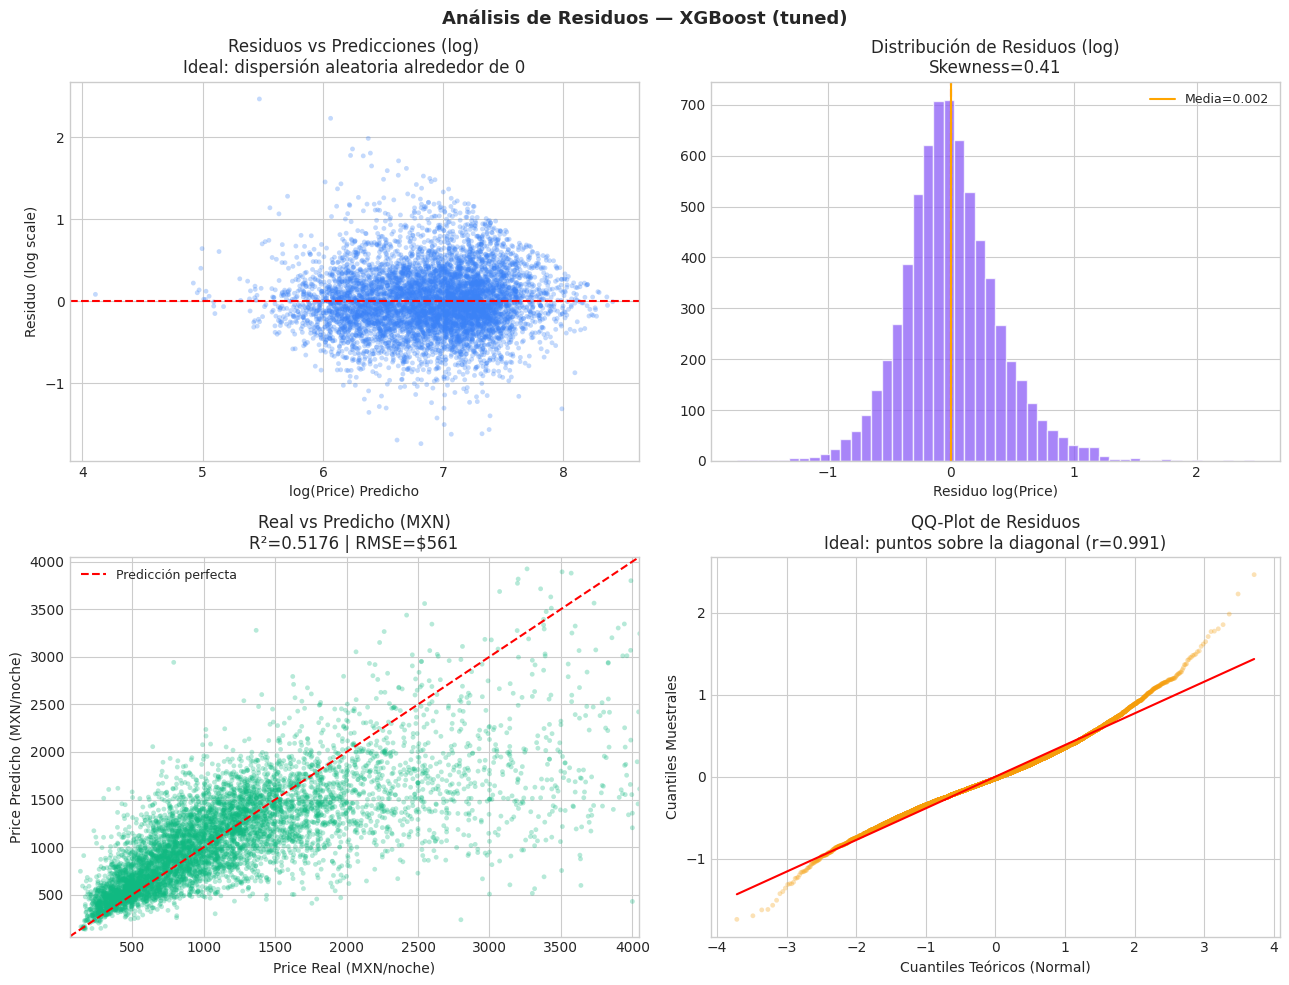

  Fig 1 guardada: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/reports/lab4/fig1_residuos.png


In [11]:
print('[9/9] Generando gráficos de análisis...')

residuos_log  = y_test_log.values  - y_pred_log_test
residuos_orig = y_test_orig.values - y_pred_test_orig

# ── Figura 1: Análisis completo de residuos ───────────────────────────────
fig1, axes = plt.subplots(2, 2, figsize=(13, 10))
fig1.suptitle(f'Análisis de Residuos — {nombre_ganador}', fontsize=13, fontweight='bold')

# 1a: Residuos vs Predichos (log)
axes[0, 0].scatter(y_pred_log_test, residuos_log, alpha=0.3, s=12,
                   color='#3b82f6', edgecolors='none')
axes[0, 0].axhline(0, color='red', lw=1.5, ls='--')
axes[0, 0].set_xlabel('log(Price) Predicho')
axes[0, 0].set_ylabel('Residuo (log scale)')
axes[0, 0].set_title('Residuos vs Predicciones (log)\nIdeal: dispersión aleatoria alrededor de 0')

# 1b: Histograma de residuos
axes[0, 1].hist(residuos_log, bins=50, color='#8b5cf6', alpha=0.75, edgecolor='white')
axes[0, 1].axvline(0, color='red', lw=1.5, ls='--')
axes[0, 1].axvline(residuos_log.mean(), color='orange', lw=1.5,
                   label=f'Media={residuos_log.mean():.3f}')
axes[0, 1].set_xlabel('Residuo log(Price)')
axes[0, 1].set_title(f'Distribución de Residuos (log)\nSkewness={pd.Series(residuos_log).skew():.2f}')
axes[0, 1].legend(fontsize=9)

# 1c: Real vs Predicho (escala original)
lim_lo = min(float(y_test_orig.min()),      float(y_pred_test_orig.min()))
lim_hi = max(float(y_test_orig.quantile(.99)), float(np.percentile(y_pred_test_orig, 99)))
axes[1, 0].scatter(y_test_orig, y_pred_test_orig, alpha=0.3, s=12,
                   color='#10b981', edgecolors='none')
axes[1, 0].plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', lw=1.5, label='Predicción perfecta')
axes[1, 0].set_xlim(lim_lo, lim_hi)
axes[1, 0].set_ylim(lim_lo, lim_hi)
axes[1, 0].set_xlabel('Price Real (MXN/noche)')
axes[1, 0].set_ylabel('Price Predicho (MXN/noche)')
axes[1, 0].set_title(f'Real vs Predicho (MXN)\nR²={r2_orig_test:.4f} | RMSE=${rmse_orig_test:,.0f}')
axes[1, 0].legend(fontsize=9)

# 1d: QQ-Plot de residuos
(osm, osr), (slope, intercept, r_qq) = stats.probplot(residuos_log, dist='norm')
axes[1, 1].scatter(osm, osr, alpha=0.3, s=12, color='#f59e0b', edgecolors='none')
axes[1, 1].plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
axes[1, 1].set_xlabel('Cuantiles Teóricos (Normal)')
axes[1, 1].set_ylabel('Cuantiles Muestrales')
axes[1, 1].set_title(f'QQ-Plot de Residuos\nIdeal: puntos sobre la diagonal (r={r_qq:.3f})')

plt.tight_layout()
fig1.savefig(REPORTS_DIR / 'fig1_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Fig 1 guardada: {REPORTS_DIR / "fig1_residuos.png"}')

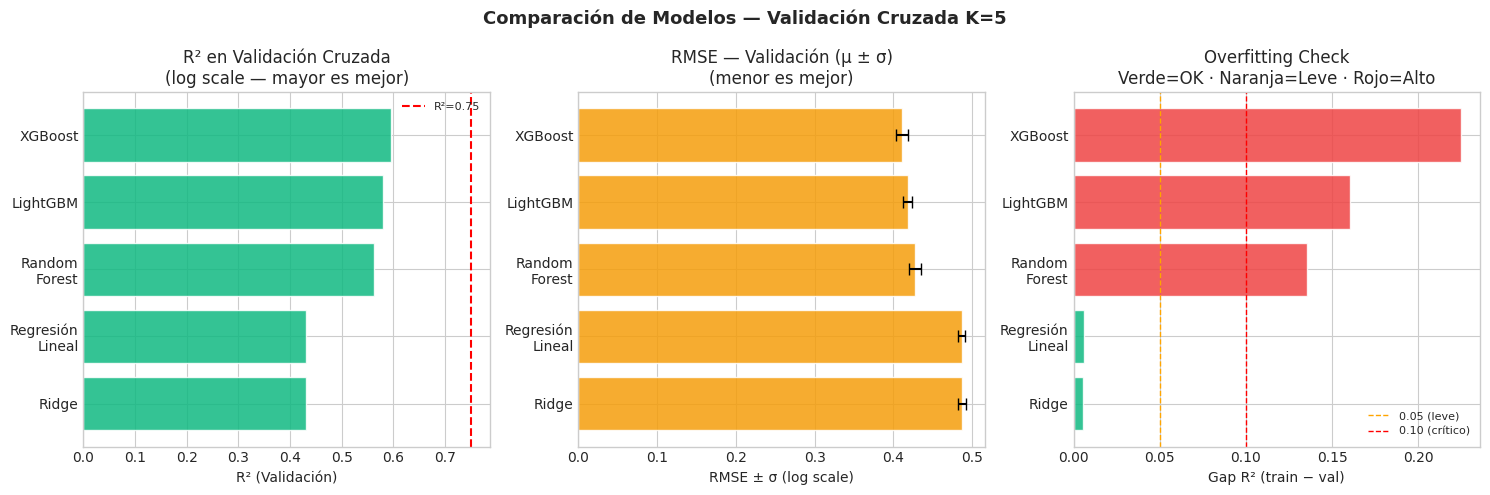

  Fig 2 guardada: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/reports/lab4/fig2_comparacion_modelos.png


In [12]:
# ── Figura 2: Comparación de modelos ──────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle('Comparación de Modelos — Validación Cruzada K=5', fontsize=13, fontweight='bold')

nombres_short = [n.replace(' ', '\n') for n in df_cv.index]

# R² validación
axes2[0].barh(nombres_short, df_cv['R²_val'], color='#10b981', alpha=0.85, edgecolor='white')
axes2[0].axvline(0.75, color='red', ls='--', lw=1.5, label='R²=0.75')
axes2[0].set_xlabel('R² (Validación)')
axes2[0].set_title('R² en Validación Cruzada\n(log scale — mayor es mejor)')
axes2[0].legend(fontsize=8)
axes2[0].invert_yaxis()

# RMSE con barras de error
axes2[1].barh(nombres_short, df_cv['RMSE_val'],
              xerr=df_cv['RMSE_std'], color='#f59e0b', alpha=0.85,
              edgecolor='white', capsize=4)
axes2[1].set_xlabel('RMSE ± σ (log scale)')
axes2[1].set_title('RMSE — Validación (µ ± σ)\n(menor es mejor)')
axes2[1].invert_yaxis()

# Gap R² (overfitting check)
gap_colors = ['#ef4444' if g > 0.10 else ('#f59e0b' if g > 0.05 else '#10b981')
              for g in df_cv['Gap_R²']]
axes2[2].barh(nombres_short, df_cv['Gap_R²'], color=gap_colors, alpha=0.85, edgecolor='white')
axes2[2].axvline(0.05, color='orange', ls='--', lw=1, label='0.05 (leve)')
axes2[2].axvline(0.10, color='red',    ls='--', lw=1, label='0.10 (crítico)')
axes2[2].set_xlabel('Gap R² (train − val)')
axes2[2].set_title('Overfitting Check\nVerde=OK · Naranja=Leve · Rojo=Alto')
axes2[2].legend(fontsize=8)
axes2[2].invert_yaxis()

plt.tight_layout()
fig2.savefig(REPORTS_DIR / 'fig2_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Fig 2 guardada: {REPORTS_DIR / "fig2_comparacion_modelos.png"}')

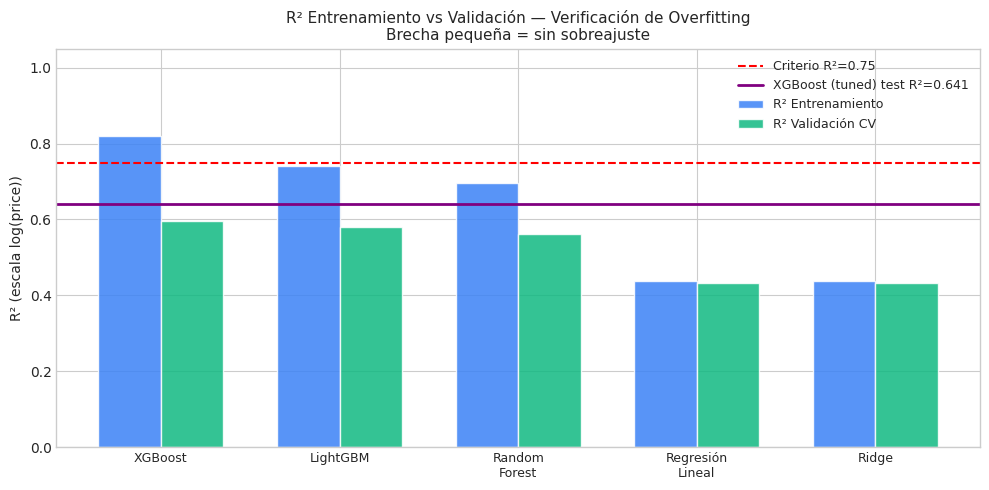

  Fig 3 guardada: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/reports/lab4/fig3_train_vs_val.png


In [13]:
# ── Figura 3: Train vs Validación (detección de overfitting) ──────────────
fig3, ax3 = plt.subplots(figsize=(10, 5))
modelos_names = list(df_cv.index)
x  = np.arange(len(modelos_names))
w  = 0.35

ax3.bar(x - w/2, df_cv['R²_train'], w, label='R² Entrenamiento',
        color='#3b82f6', alpha=0.85, edgecolor='white')
ax3.bar(x + w/2, df_cv['R²_val'],   w, label='R² Validación CV',
        color='#10b981', alpha=0.85, edgecolor='white')

# Línea del criterio y resultado final
ax3.axhline(0.75, color='red', ls='--', lw=1.5, label='Criterio R²=0.75')
ax3.axhline(r2_log_test, color='purple', ls='-', lw=2,
            label=f'{nombre_ganador} test R²={r2_log_test:.3f}')

ax3.set_xticks(x)
ax3.set_xticklabels([n.replace(' ', '\n') for n in modelos_names], fontsize=9)
ax3.set_ylabel('R² (escala log(price))')
ax3.set_title('R² Entrenamiento vs Validación — Verificación de Overfitting\n'
              'Brecha pequeña = sin sobreajuste', fontsize=11)
ax3.legend(fontsize=9)
ax3.set_ylim(0, 1.05)

plt.tight_layout()
fig3.savefig(REPORTS_DIR / 'fig3_train_vs_val.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Fig 3 guardada: {REPORTS_DIR / "fig3_train_vs_val.png"}')

## 10. Importancia de Variables

Se analiza la importancia de las features en el modelo final (basada en **gain**,
que mide la reducción de impureza ponderada por el número de veces que cada feature
es usada en los splits del árbol).

La curva de importancia acumulada muestra cuántas variables son necesarias para
explicar el 80% y 90% de la capacidad predictiva del modelo.

Importancia de Variables...
  Top 5 variables más influyentes: ['room_type_Shared room', 'is_entire_flag', 'room_type_Private room', 'neighbourhood_Iztapalapa', 'is_studio']


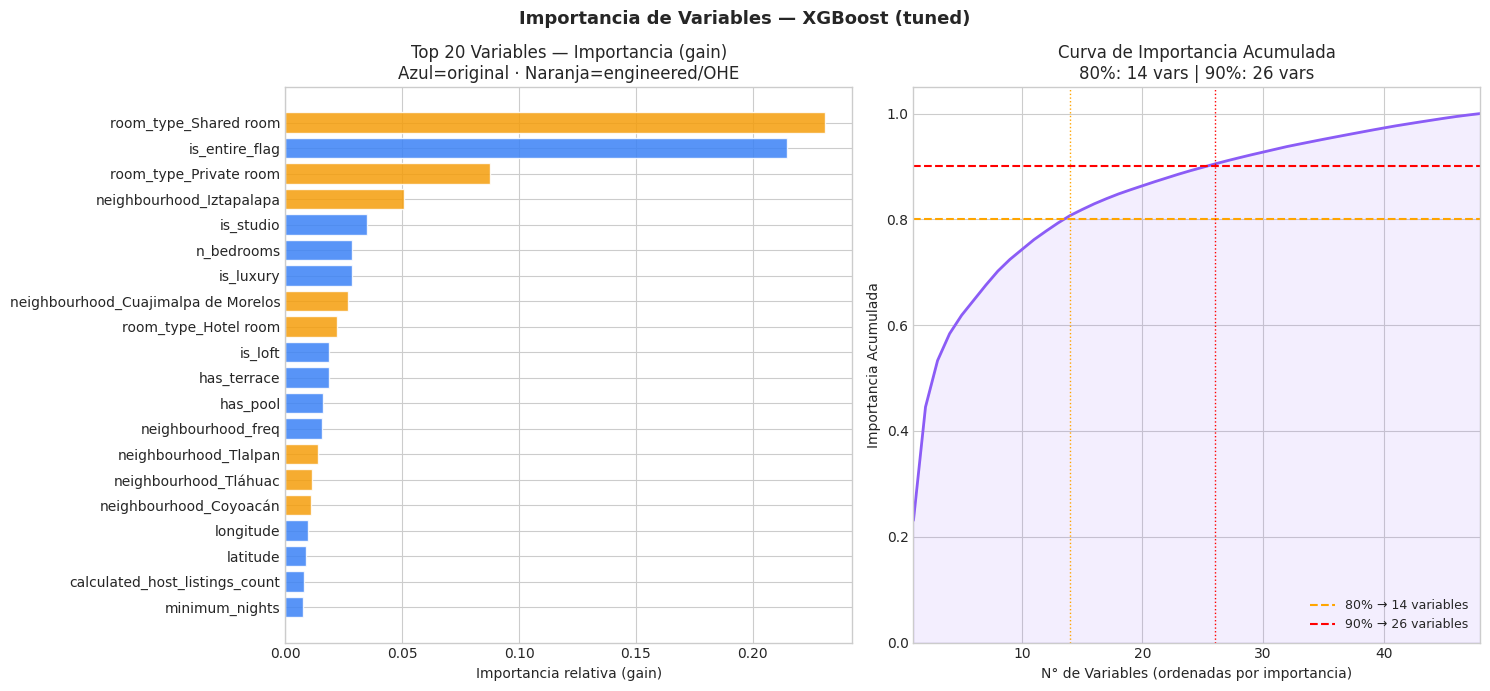

  Fig 4 guardada: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/reports/lab4/fig4_importancia.png


In [14]:
print('Importancia de Variables...')

fig4, axes4 = plt.subplots(1, 2, figsize=(15, 7))
fig4.suptitle(f'Importancia de Variables — {nombre_ganador}', fontsize=13, fontweight='bold')

try:
    prep_fitted = modelo_final_pipe.named_steps['prep']
    ohe         = prep_fitted.named_transformers_['cat'].named_steps['encoder']
    cat_names   = ohe.get_feature_names_out(FEATURES_CAT).tolist()
    all_names   = FEATURES_NUM + cat_names

    importancias = modelo_final_pipe.named_steps['model'].feature_importances_
    n = min(len(importancias), len(all_names))
    imp = pd.Series(importancias[:n], index=all_names[:n]).sort_values(ascending=False)

    # Top 20 más importantes
    top20 = imp.head(20)
    colors_imp = ['#3b82f6' if i in FEATURES_NUM else '#f59e0b' for i in top20.index]
    axes4[0].barh(top20.index[::-1], top20.values[::-1], color=colors_imp[::-1], alpha=0.85, edgecolor='white')
    axes4[0].set_title('Top 20 Variables — Importancia (gain)\nAzul=original · Naranja=engineered/OHE')
    axes4[0].set_xlabel('Importancia relativa (gain)')

    # Curva de importancia acumulada
    cumsum = np.cumsum(imp.values) / imp.sum()
    n80    = int(np.searchsorted(cumsum, 0.80)) + 1
    n90    = int(np.searchsorted(cumsum, 0.90)) + 1
    axes4[1].plot(range(1, len(cumsum) + 1), cumsum, color='#8b5cf6', lw=2)
    axes4[1].fill_between(range(1, len(cumsum) + 1), cumsum, alpha=0.1, color='#8b5cf6')
    axes4[1].axhline(0.80, color='orange', ls='--', lw=1.5, label=f'80% → {n80} variables')
    axes4[1].axhline(0.90, color='red',    ls='--', lw=1.5, label=f'90% → {n90} variables')
    axes4[1].axvline(n80, color='orange', ls=':', lw=1)
    axes4[1].axvline(n90, color='red',    ls=':', lw=1)
    axes4[1].set_xlabel('N° de Variables (ordenadas por importancia)')
    axes4[1].set_ylabel('Importancia Acumulada')
    axes4[1].set_title(f'Curva de Importancia Acumulada\n80%: {n80} vars | 90%: {n90} vars')
    axes4[1].legend(fontsize=9)
    axes4[1].set_xlim(1, len(cumsum))
    axes4[1].set_ylim(0, 1.05)

    print(f'  Top 5 variables más influyentes: {list(imp.head(5).index)}')

except Exception as e:
    print(f'  No se pudo generar gráfico: {e}')
    for ax in axes4:
        ax.text(0.5, 0.5, 'No disponible', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
fig4.savefig(REPORTS_DIR / 'fig4_importancia.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Fig 4 guardada: {REPORTS_DIR / "fig4_importancia.png"}')

## 11. Resumen Ejecutivo

Tabla consolidada con métricas de todos los modelos y el resultado final en test.

In [15]:
print('=' * 70)
print('  RESUMEN EJECUTIVO — LAB 4 REGRESIÓN')
print('=' * 70)

# Tabla consolidada de todos los modelos + modelo final en test
rows = []
for nombre in df_cv.index:
    rows.append({
        'Modelo':         nombre,
        'R²_val (log)':   df_cv.loc[nombre, 'R²_val'],
        'RMSE_val (log)': df_cv.loc[nombre, 'RMSE_val'],
        'Gap_R²':         df_cv.loc[nombre, 'Gap_R²'],
        'R²_test (orig)': '—',
        'MAE_test (MXN)': '—',
    })

rows.append({
    'Modelo':         f'{nombre_ganador} [FINAL]',
    'R²_val (log)':   r2_log_test,
    'RMSE_val (log)': rmse_log_test,
    'Gap_R²':         gap_r2,
    'R²_test (orig)': r2_orig_test,
    'MAE_test (MXN)': f'${mae_orig_test:,.0f}',
})

df_resumen = pd.DataFrame(rows).set_index('Modelo')
display(df_resumen)

r2_ok  = r2_orig_test >= 0.75
gap_ok = gap_r2 < 0.10
print(f'\n  {"✅" if r2_ok else "⚠"} Criterio R² ≥ 0.75 en test: {r2_orig_test:.4f}')
print(f'  {"✅" if gap_ok else "⚠"} Sin overfitting (Gap < 0.10): {gap_r2:.4f}')
print(f'\n  Figuras guardadas en: {REPORTS_DIR}')
print(f'  Modelo guardado en:   {MODELS_DIR}')

  RESUMEN EJECUTIVO — LAB 4 REGRESIÓN


,R²_val (log),RMSE_val (log),Gap_R²,R²_test (orig),MAE_test (MXN)
Modelo,,,,,
XGBoost,0.595693,0.410788,0.224587,—,—
LightGBM,0.580727,0.418311,0.160342,—,—
Random Forest,0.561892,0.427612,0.135557,—,—
Regresión Lineal,0.432029,0.486835,0.006065,—,—
Ridge,0.431738,0.486963,0.005708,—,—
XGBoost (tuned) [FINAL],0.641457,0.389768,0.339095,0.517627,$353



  ⚠ Criterio R² ≥ 0.75 en test: 0.5176
  ⚠ Sin overfitting (Gap < 0.10): 0.3391

  Figuras guardadas en: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/reports/lab4
  Modelo guardado en:   /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/models


## 12. Guardado del Modelo

Se serializa el pipeline completo (preprocesamiento + modelo) con `joblib`.
Guardar el pipeline completo garantiza que las mismas transformaciones aplicadas
durante el entrenamiento se apliquen automáticamente en producción.

In [16]:
print('[+] Guardando modelo final...')

model_path    = MODELS_DIR / 'model_regression.joblib'
features_path = MODELS_DIR / 'features_regression.joblib'
meta_path     = MODELS_DIR / 'model_metadata.joblib'

joblib.dump(modelo_final_pipe, model_path)
joblib.dump({'numericas': FEATURES_NUM, 'categoricas': FEATURES_CAT}, features_path)
joblib.dump({
    'nombre_modelo':     nombre_ganador,
    'r2_test_original':  r2_orig_test,
    'r2_test_log':       r2_log_test,
    'mae_test_mxn':      mae_orig_test,
    'rmse_test_mxn':     rmse_orig_test,
    'gap_r2':            gap_r2,
    'target_transform':  'log → exp para inferencia',
    'fecha_entrenamiento': str(datetime.now().date()),
}, meta_path)

print(f'  ✔ Pipeline: {model_path}')
print(f'  ✔ Features: {features_path}')
print(f'  ✔ Metadata: {meta_path}')

# Verificación de carga y predicción
loaded     = joblib.load(model_path)
preds_test = np.exp(loaded.predict(X_test.iloc[:3]))
print('\n  Verificación — primeras 3 predicciones (MXN/noche):')
for i, (pred, real) in enumerate(zip(preds_test, y_test_orig.values[:3])):
    err_pct = abs(pred - real) / real * 100
    print(f'    [{i+1}] Predicho=${pred:,.0f}  |  Real=${real:,.0f}  |  Error={err_pct:.1f}%')

print('\n  Pipeline serializado y verificado. Listo para inferencia.')

[+] Guardando modelo final...
  ✔ Pipeline: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/models/model_regression.joblib
  ✔ Features: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/models/features_regression.joblib
  ✔ Metadata: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/models/model_metadata.joblib



  Verificación — primeras 3 predicciones (MXN/noche):
    [1] Predicho=$435  |  Real=$723  |  Error=39.8%
    [2] Predicho=$1,470  |  Real=$1,007  |  Error=46.0%
    [3] Predicho=$583  |  Real=$477  |  Error=22.1%

  Pipeline serializado y verificado. Listo para inferencia.


---

## OPTIMIZACIÓN — Ingeniería de Datos Avanzada v2

**Objetivo:** superar el R²_log = 0.6254 del baseline XGBoost, reducir el Gap R² = 0.1549 (overfitting) y bajar el MAE por debajo de 300 MXN/noche.

| Técnica | Impacto esperado |
|---|---|
| **Distancias geográficas** (Zócalo, Polanco, Condesa, Reforma, etc.) | **Alto** — captura gradiente de precios por zona premium |
| **Text mining ampliado** (wifi, AC, cocina, jacuzzi, gimnasio, vista) | **Medio** — extrae señal adicional del campo `name` |
| **Luxury score** + interacciones (lujo × tipo) | **Medio** — diferencia listings premium de budget |
| **TargetEncoder** en `neighbourhood` (sin leakage) | **Alto** — precio medio del barrio como feature directa |
| **Review momentum** (nro_reviews × reviews/mes) | **Medio** — proxy de demanda/popularidad |
| **LightGBM + Optuna** (60 trials Bayesianos, KFold-5) | **Alto** — exploración eficiente vs. 15 iter random |
| **Ensemble XGBoost + LightGBM** (pesos inversos al RMSE) | **Medio** — reduce varianza del predictor final |

> Se usa la **misma división 70/30** (mismo `random_state`) y el **mismo filtro de outliers**  
> para garantizar comparabilidad exacta con el baseline del Lab 4.

In [17]:
print('[OPT — 0/7] Importaciones adicionales para optimización...')

import sklearn
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.preprocessing import TargetEncoder
from sklearn.ensemble import VotingRegressor

print(f'  optuna        : {optuna.__version__}')
print(f'  TargetEncoder : OK (sklearn {sklearn.__version__})')

# ── Coordenadas de zonas clave de CDMX ────────────────────────────────────
LANDMARKS_V2 = {
    'dist_zocalo':    (19.4326, -99.1332),  # Centro Histórico — turismo masivo
    'dist_polanco':   (19.4338, -99.1918),  # Polanco — zona de lujo
    'dist_condesa':   (19.4108, -99.1731),  # Condesa — trendy / lifestyle
    'dist_reforma':   (19.4226, -99.1676),  # Paseo de la Reforma — negocios
    'dist_airport':   (19.4363, -99.0727),  # AICM — proximidad a aeropuerto
    'dist_santa_fe':  (19.3610, -99.2630),  # Santa Fe — negocios corporativos
    'dist_coyoacan':  (19.3502, -99.1624),  # Coyoacán — turismo cultural
}

print(f'  Zonas de referencia geográfica: {len(LANDMARKS_V2)}')
print('  Listo para optimización.')

[OPT — 0/7] Importaciones adicionales para optimización...


  optuna        : 4.9.0
  TargetEncoder : OK (sklearn 1.8.0)
  Zonas de referencia geográfica: 7
  Listo para optimización.


In [18]:
print('[OPT — 1/7] Ingeniería de Características Avanzada v2...')
print('            (aplica sobre df_eng que conserva todas las columnas originales)')

def add_v2_features(df_input):
    """
    Añade 24 features nuevas sobre el resultado de engineer_features():
      - 8 distancias geográficas a zonas clave CDMX
      - 8 features de texto ampliadas (amenidades, tipo de propiedad)
      - 3 de texto: luxury_score, title_length, word_count
      - 1 host: is_professional_host
      - 4 interacciones: review_momentum, luxury_entire,
                         active_and_booked, log_avail_per_rev
    """
    df = df_input.copy()

    # 1. DISTANCIAS GEOGRÁFICAS (grados × 111 ≈ km en latitudes de México)
    for feat, (lat, lon) in LANDMARKS_V2.items():
        df[feat] = (np.sqrt(
            (df['latitude']  - lat) ** 2 +
            (df['longitude'] - lon) ** 2
        ) * 111.0)

    # Distancia mínima a cualquier zona premium (Polanco / Condesa / Reforma)
    df['dist_premium_zone'] = df[['dist_polanco',
                                   'dist_condesa',
                                   'dist_reforma']].min(axis=1)

    # 2. TEXT MINING AMPLIADO desde el campo 'name'
    names = df['name'].fillna('').str.lower()

    df['has_wifi']      = names.str.contains(
                              r'wifi|wi-fi|internet', regex=True).astype(int)
    df['has_ac']        = names.str.contains(
                              r'\bac\b|a/c|aire\s*acond|air\s*cond', regex=True).astype(int)
    df['has_kitchen']   = names.str.contains(
                              r'kitchen|cocina|kitchenette', regex=True).astype(int)
    df['has_jacuzzi']   = names.str.contains(
                              r'jacuzzi|hidromasaje|whirlpool|tina', regex=True).astype(int)
    df['has_gym']       = names.str.contains(
                              r'\bgym\b|gimnasio|fitness', regex=True).astype(int)
    df['has_view']      = names.str.contains(
                              r'\bview\b|vista|panoram|skyline', regex=True).astype(int)
    df['is_apartment']  = names.str.contains(
                              r'apartment|departamento|depto|dpto|apto', regex=True).astype(int)
    df['is_house']      = names.str.contains(
                              r'\bhouse\b|\bcasa\b|chalet|villa\b', regex=True).astype(int)

    # Score de lujo (0-5): cuenta keywords premium en el título
    df['luxury_score']  = (names
                           .str.count(r'luxury|lujo|premium|deluxe|vip|penthouse|suite|exclusiv')
                           .clip(0, 5).astype(int))

    df['title_length']  = df['name'].fillna('').str.len().clip(0, 120).astype(int)
    df['word_count']    = (df['name'].fillna('').str.split()
                           .str.len().fillna(0).clip(0, 25).astype(int))

    # 3. FEATURE DE HOST
    df['is_professional_host'] = (df['calculated_host_listings_count'] >= 5).astype(int)

    # 4. INTERACCIONES
    # Momentum de reseñas: señal de popularidad/demanda reciente
    df['review_momentum'] = np.log1p(
        df['number_of_reviews'] * df['reviews_per_month'].fillna(0)
    )

    # Listing de lujo Y habitación completa (premium combinado)
    df['luxury_entire'] = (df['is_luxury'] * df['is_entire_flag']).astype(int)

    # Activo Y baja disponibilidad → alta demanda → precio mayor
    df['active_and_booked'] = (
        df['is_recently_active'] * (1.0 - df['availability_ratio'])
    )

    # Disponibilidad relativa al nro de reviews (proxy de ocupación real)
    df['log_avail_per_rev'] = np.log1p(
        df['availability_365'] / (df['number_of_reviews'] + 1.0)
    )

    return df


# Aplicar sobre df_eng (tiene todas las columnas raw + features v1)
df_eng_v2 = add_v2_features(df_eng)

NEW_FEATS = [
    'dist_zocalo', 'dist_polanco', 'dist_condesa', 'dist_reforma',
    'dist_airport', 'dist_santa_fe', 'dist_coyoacan', 'dist_premium_zone',
    'has_wifi', 'has_ac', 'has_kitchen', 'has_jacuzzi', 'has_gym', 'has_view',
    'is_apartment', 'is_house', 'luxury_score', 'title_length', 'word_count',
    'is_professional_host',
    'review_momentum', 'luxury_entire', 'active_and_booked', 'log_avail_per_rev',
]

print(f'  Features nuevas añadidas: {len(NEW_FEATS)}')
print()

# Tasas de presencia en el dataset (pct_stats: no sobreescribir scipy.stats)
binary_feats = [f for f in NEW_FEATS
                if df_eng_v2[f].dtype in ['int64', 'int32', 'float64']
                and df_eng_v2[f].max() <= 1]
pct_stats = pd.DataFrame(
    {'presencia_%': [df_eng_v2[f].mean() * 100 for f in binary_feats]},
    index=binary_feats
)
print('  Resumen de features de texto y amenidades:')
print(pct_stats.round(1).to_string())
print()
print(f'  luxury_score>0: {(df_eng_v2["luxury_score"]>0).mean()*100:.1f}% de los listings')
print(f'  dist_polanco media: {df_eng_v2["dist_polanco"].mean():.2f} km')
print(f'  dist_premium_zone media: {df_eng_v2["dist_premium_zone"].mean():.2f} km')

[OPT — 1/7] Ingeniería de Características Avanzada v2...
            (aplica sobre df_eng que conserva todas las columnas originales)


  Features nuevas añadidas: 24



  Resumen de features de texto y amenidades:
                      presencia_%
has_wifi                      1.5
has_ac                        2.1
has_kitchen                   0.7
has_jacuzzi                   0.5
has_gym                       3.0
has_view                      3.2
is_apartment                 22.5
is_house                      7.5
is_professional_host         46.4
luxury_entire                 6.1
active_and_booked            22.2

  luxury_score>0: 10.0% de los listings
  dist_polanco media: 5.80 km
  dist_premium_zone media: 3.68 km


In [19]:
print('[OPT — 2/7] Definición de features v2, outlier treatment y train/test split...')

# Feature set v2:
#   - FEATURES_NUM sin 'neighbourhood_freq' (reemplazada por TargetEncoder en pipeline)
#   - + todas las features nuevas (NEW_FEATS)
FEATURES_NUM_V2 = [f for f in FEATURES_NUM if f != 'neighbourhood_freq'] + NEW_FEATS
FEATURES_CAT_V2 = ['room_type', 'neighbourhood']   # neighbourhood → TargetEncoder

all_feats_v2 = FEATURES_NUM_V2 + FEATURES_CAT_V2

# Verificar que todas las columnas existen
missing_v2 = [c for c in all_feats_v2 if c not in df_eng_v2.columns]
if missing_v2:
    raise ValueError(f'Columnas faltantes en df_eng_v2: {missing_v2}')

# ── Mismo filtro de outliers que en la sección 4 ─────────────────────────
# 'upper' fue calculado antes: upper = min(Q3 + 3·IQR, p99)
df_model_v2  = df_eng_v2[all_feats_v2 + ['price']].copy()
df_clean_v2  = df_model_v2[df_model_v2['price'] <= upper].copy()
df_clean_v2['log_price'] = np.log(df_clean_v2['price'])

print(f'  Dataset v2 (post-outlier): {len(df_clean_v2):,} filas  '
      f'(idéntico al v1: {len(df_clean):,})')

# ── Misma división 70/30 estratificada ───────────────────────────────────
X_v2       = df_clean_v2[FEATURES_NUM_V2 + FEATURES_CAT_V2]
y_log_v2   = df_clean_v2['log_price']
y_orig_v2  = df_clean_v2['price']

(X_train_v2, X_test_v2,
 y_train_v2, y_test_v2,
 y_tr_orig_v2, y_te_orig_v2) = train_test_split(
    X_v2, y_log_v2, y_orig_v2,
    test_size=0.30, random_state=RANDOM_STATE,
    stratify=df_clean_v2['room_type']
)

print(f'  Train: {X_train_v2.shape[0]:,}  |  Test: {X_test_v2.shape[0]:,}')
print(f'  Features numéricas v2 : {len(FEATURES_NUM_V2)}  '
      f'(+{len(NEW_FEATS)} nuevas vs v1)')
print(f'  Features categóricas  : {FEATURES_CAT_V2}')

# ── Correlaciones de las NUEVAS features con log(price) ──────────────────
tmp_corr = df_clean_v2[NEW_FEATS + ['log_price']].corr()['log_price'].drop('log_price')
tmp_corr = tmp_corr.sort_values(key=abs, ascending=False)

print('\n  Top correlaciones de NUEVAS features con log(price):')
print(tmp_corr.round(3).to_string())
del tmp_corr

[OPT — 2/7] Definición de features v2, outlier treatment y train/test split...
  Dataset v2 (post-outlier): 22,712 filas  (idéntico al v1: 22,712)
  Train: 15,898  |  Test: 6,814
  Features numéricas v2 : 53  (+24 nuevas vs v1)
  Features categóricas  : ['room_type', 'neighbourhood']

  Top correlaciones de NUEVAS features con log(price):
dist_polanco           -0.310
dist_premium_zone      -0.297
dist_condesa           -0.273
dist_reforma           -0.265
dist_santa_fe          -0.211
word_count              0.172
luxury_entire           0.146
has_gym                 0.136
luxury_score            0.127
title_length            0.125
dist_zocalo            -0.114
is_apartment            0.108
has_ac                  0.098
is_professional_host    0.096
has_view                0.076
review_momentum         0.054
dist_airport            0.051
active_and_booked       0.050
has_jacuzzi             0.048
is_house                0.041
log_avail_per_rev      -0.036
has_kitchen            -0.028

In [20]:
print('[OPT — 3/7] Preprocesador v2 con TargetEncoder para neighbourhood...')
print()
print('  Diseño del pipeline:')
print('    ┌─ Numérico  (53 feat) → SimpleImputer(median) + RobustScaler')
print('    ├─ room_type  (1 feat) → SimpleImputer(moda) + OHE(drop=first)')
print('    └─ neighbourhood (1)  → SimpleImputer(moda) + TargetEncoder(smooth=auto, cv=5)')
print()
print('  TargetEncoder: codifica cada barrio con el precio-log promedio')
print('  suavizado (Bayesian shrinkage) calculado en folds internos (cv=5).')
print('  Al usarse dentro de cross_validate, se ajusta SOLO en el fold de')
print('  entrenamiento → sin data leakage de precio.')

# ── Preprocesador numérico ────────────────────────────────────────────────
prep_num_v2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

# ── room_type → OHE ──────────────────────────────────────────────────────
prep_room_v2 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False, drop='first')),
])

# ── neighbourhood → TargetEncoder ────────────────────────────────────────
# smooth='auto' usa suavizado de Bayes (James-Stein estimator)
# cv=5: cross-fitting interno en el set de entrenamiento para debiasing
prep_neigh_v2 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('te',      TargetEncoder(smooth='auto',
                              target_type='continuous',
                              cv=5,
                              random_state=RANDOM_STATE)),
])

preprocessor_v2 = ColumnTransformer([
    ('num',   prep_num_v2,   FEATURES_NUM_V2),
    ('room',  prep_room_v2,  ['room_type']),
    ('neigh', prep_neigh_v2, ['neighbourhood']),
], remainder='drop')

# KFold-5 para la búsqueda de hiperparámetros (más robusto que K=3)
kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Test rápido del preprocesador ─────────────────────────────────────────
_pipe_test = Pipeline([
    ('prep', preprocessor_v2),
    ('model', Ridge())
])
_cv = cross_validate(_pipe_test, X_train_v2, y_train_v2, cv=3,
                     scoring='r2', return_train_score=True)
r2_ridge_v2 = _cv['test_score'].mean()
print(f'\n  Sanity check — Ridge con features v2 (K=3):')
print(f'    R²_val   = {r2_ridge_v2:.4f}  '
      f'(baseline Ridge v1: {df_cv.loc["Ridge","R²_val"]:.4f})')
delta = r2_ridge_v2 - df_cv.loc['Ridge','R²_val']
print(f'    Delta    = {delta:+.4f}  '
      f'→ {"✅ mejora" if delta > 0 else "⚠ verifica features"} de feature engineering')
del _pipe_test, _cv

[OPT — 3/7] Preprocesador v2 con TargetEncoder para neighbourhood...

  Diseño del pipeline:
    ┌─ Numérico  (53 feat) → SimpleImputer(median) + RobustScaler
    ├─ room_type  (1 feat) → SimpleImputer(moda) + OHE(drop=first)
    └─ neighbourhood (1)  → SimpleImputer(moda) + TargetEncoder(smooth=auto, cv=5)

  TargetEncoder: codifica cada barrio con el precio-log promedio
  suavizado (Bayesian shrinkage) calculado en folds internos (cv=5).
  Al usarse dentro de cross_validate, se ajusta SOLO en el fold de
  entrenamiento → sin data leakage de precio.



  Sanity check — Ridge con features v2 (K=3):
    R²_val   = 0.4619  (baseline Ridge v1: 0.4317)
    Delta    = +0.0302  → ✅ mejora de feature engineering


In [21]:
print('[OPT — 4/7] Optimización LightGBM con Optuna (60 trials Bayesianos, KFold-5)...')
print('  Esto puede tardar 5-8 minutos. Optuna explora el espacio de hiperparámetros')
print('  con TPE Sampler (Tree-structured Parzen Estimator) — ~4× más eficiente')
print('  que RandomizedSearchCV para encontrar la región óptima.')
print()

def _objective_lgb(trial):
    """Función objetivo: minimizar RMSE CV en log(price)."""
    params = {
        'n_estimators':      trial.suggest_int('n_estimators',      400,  2000),
        'learning_rate':     trial.suggest_float('learning_rate',   0.008, 0.08, log=True),
        'max_depth':         trial.suggest_int('max_depth',         4,    9),
        'num_leaves':        trial.suggest_int('num_leaves',        20,   100),
        'min_child_samples': trial.suggest_int('min_child_samples', 15,   150),
        'subsample':         trial.suggest_float('subsample',       0.55, 1.0),
        'subsample_freq':    trial.suggest_int('subsample_freq',    1,    5),
        'colsample_bytree':  trial.suggest_float('colsample_bytree',0.50, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha',       1e-7, 8.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',      1e-7, 8.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain',  0.0,  0.5),
    }
    pipe = Pipeline([
        ('prep',  preprocessor_v2),
        ('model', LGBMRegressor(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=2,          # 2 jobs internos para LGB
            verbose=-1,
        )),
    ])
    scores = cross_validate(
        pipe, X_train_v2, y_train_v2,
        cv=kf5,
        scoring='neg_root_mean_squared_error',
        n_jobs=1,              # 1 job externo: evita deadlock con LGB n_jobs>1
    )
    return (-scores['test_score']).mean()


study_lgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=12),
)

study_lgb.optimize(
    _objective_lgb,
    n_trials=60,
    timeout=600,    # máx 10 min
    show_progress_bar=True,
)

best_lgb_params = study_lgb.best_params
best_lgb_cv_rmse = study_lgb.best_value

print(f'\n  ═══ Resultado LightGBM Optuna ═══')
print(f'  Trials completados : {len(study_lgb.trials)}')
print(f'  RMSE CV (LGBMv2)   : {best_lgb_cv_rmse:.5f}')
print(f'  RMSE CV (XGB base) : {df_cv.loc["XGBoost","RMSE_val"]:.5f}')
mejora_lgb = (df_cv.loc['XGBoost','RMSE_val'] - best_lgb_cv_rmse) / df_cv.loc['XGBoost','RMSE_val'] * 100
print(f'  Mejora vs baseline : {mejora_lgb:+.1f}%  '
      f'{"✅" if mejora_lgb > 0 else "⚠"}')
print(f'\n  Mejores parámetros:')
for k, v in best_lgb_params.items():
    fmtv = f'{v:.5g}' if isinstance(v, float) else str(v)
    print(f'    {k:<22}: {fmtv}')

[OPT — 4/7] Optimización LightGBM con Optuna (60 trials Bayesianos, KFold-5)...
  Esto puede tardar 5-8 minutos. Optuna explora el espacio de hiperparámetros
  con TPE Sampler (Tree-structured Parzen Estimator) — ~4× más eficiente
  que RandomizedSearchCV para encontrar la región óptima.



  0%|          | 0/60 [00:00<?, ?it/s]


  ═══ Resultado LightGBM Optuna ═══
  Trials completados : 33
  RMSE CV (LGBMv2)   : 0.38886
  RMSE CV (XGB base) : 0.41079
  Mejora vs baseline : +5.3%  ✅

  Mejores parámetros:
    n_estimators          : 1439
    learning_rate         : 0.024635
    max_depth             : 9
    num_leaves            : 78
    min_child_samples     : 31
    subsample             : 0.89118
    subsample_freq        : 3
    colsample_bytree      : 0.54036
    reg_alpha             : 7.2843e-05
    reg_lambda            : 1.89
    min_split_gain        : 0.0527


In [22]:
print('[OPT — 5/7] Optimización XGBoost v2 con Optuna (40 trials, KFold-5)...')
print()

def _objective_xgb(trial):
    """Función objetivo XGBoost: minimizar RMSE CV en log(price)."""
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',     300,  1800),
        'learning_rate':    trial.suggest_float('learning_rate',  0.008, 0.10, log=True),
        'max_depth':        trial.suggest_int('max_depth',        4,    9),
        'subsample':        trial.suggest_float('subsample',      0.55, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.50, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1,    25),
        'reg_alpha':        trial.suggest_float('reg_alpha',      1e-7, 8.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda',     1e-7, 8.0, log=True),
        'gamma':            trial.suggest_float('gamma',          0.0,  0.5),
        'max_delta_step':   trial.suggest_int('max_delta_step',   0,    5),
    }
    pipe = Pipeline([
        ('prep',  preprocessor_v2),
        ('model', XGBRegressor(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=2,
            verbosity=0,
            tree_method='hist',   # más rápido en CPU
        )),
    ])
    scores = cross_validate(
        pipe, X_train_v2, y_train_v2,
        cv=kf5,
        scoring='neg_root_mean_squared_error',
        n_jobs=1,
    )
    return (-scores['test_score']).mean()


study_xgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 1),
)

study_xgb.optimize(
    _objective_xgb,
    n_trials=40,
    timeout=480,   # máx 8 min
    show_progress_bar=True,
)

best_xgb_params = study_xgb.best_params
best_xgb_cv_rmse = study_xgb.best_value

print(f'\n  ═══ Resultado XGBoost v2 Optuna ═══')
print(f'  Trials completados : {len(study_xgb.trials)}')
print(f'  RMSE CV (XGBv2)    : {best_xgb_cv_rmse:.5f}')
print(f'  RMSE CV (LGBMv2)   : {best_lgb_cv_rmse:.5f}')
print(f'  RMSE CV (XGB base) : {df_cv.loc["XGBoost","RMSE_val"]:.5f}')
mejora_xgb = (df_cv.loc['XGBoost','RMSE_val'] - best_xgb_cv_rmse) / df_cv.loc['XGBoost','RMSE_val'] * 100
print(f'  Mejora XGBv2       : {mejora_xgb:+.1f}%')
print(f'\n  Mejores parámetros XGBoost v2:')
for k, v in best_xgb_params.items():
    fmtv = f'{v:.5g}' if isinstance(v, float) else str(v)
    print(f'    {k:<22}: {fmtv}')

[OPT — 5/7] Optimización XGBoost v2 con Optuna (40 trials, KFold-5)...



  0%|          | 0/40 [00:00<?, ?it/s]


  ═══ Resultado XGBoost v2 Optuna ═══
  Trials completados : 24
  RMSE CV (XGBv2)    : 0.38918
  RMSE CV (LGBMv2)   : 0.38886
  RMSE CV (XGB base) : 0.41079
  Mejora XGBv2       : +5.3%

  Mejores parámetros XGBoost v2:
    n_estimators          : 1730
    learning_rate         : 0.022645
    max_depth             : 9
    subsample             : 0.85248
    colsample_bytree      : 0.81439
    min_child_weight      : 7
    reg_alpha             : 1.222
    reg_lambda            : 4.316e-06
    gamma                 : 0.2022
    max_delta_step        : 5


In [23]:
print('[OPT — 6/7] Entrenamiento final + Ensemble ponderado...')
print()

# ── Pipelines con mejores hiperparámetros encontrados por Optuna ──────────
pipe_lgb_final = Pipeline([
    ('prep',  preprocessor_v2),
    ('model', LGBMRegressor(
        **best_lgb_params,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )),
])

pipe_xgb_final = Pipeline([
    ('prep',  preprocessor_v2),
    ('model', XGBRegressor(
        **best_xgb_params,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        tree_method='hist',
    )),
])

# ── Entrenar sobre TODO el set de entrenamiento ───────────────────────────
print('  Entrenando LightGBM v2 (todos los datos de train)...')
pipe_lgb_final.fit(X_train_v2, y_train_v2)

print('  Entrenando XGBoost  v2 (todos los datos de train)...')
pipe_xgb_final.fit(X_train_v2, y_train_v2)

# ── Predicciones individuales ─────────────────────────────────────────────
pred_lgb_log_tr  = pipe_lgb_final.predict(X_train_v2)
pred_lgb_log_te  = pipe_lgb_final.predict(X_test_v2)
pred_xgb_log_tr  = pipe_xgb_final.predict(X_train_v2)
pred_xgb_log_te  = pipe_xgb_final.predict(X_test_v2)

# ── Ensemble: pesos inversos al RMSE CV (mejor modelo → más peso) ─────────
w_lgb  = 1.0 / best_lgb_cv_rmse
w_xgb  = 1.0 / best_xgb_cv_rmse
w_sum  = w_lgb + w_xgb
wn_lgb = w_lgb / w_sum
wn_xgb = w_xgb / w_sum

pred_ens_log_tr = wn_lgb * pred_lgb_log_tr + wn_xgb * pred_xgb_log_tr
pred_ens_log_te = wn_lgb * pred_lgb_log_te + wn_xgb * pred_xgb_log_te

print(f'\n  Pesos del ensemble:')
print(f'    LightGBM : {wn_lgb:.3f}  (RMSE CV={best_lgb_cv_rmse:.4f})')
print(f'    XGBoost  : {wn_xgb:.3f}  (RMSE CV={best_xgb_cv_rmse:.4f})')

# ── Función de métricas ───────────────────────────────────────────────────
def metricas(y_log_true, y_log_pred, y_orig_true, label=''):
    y_orig_pred = np.exp(y_log_pred)
    r2l  = r2_score(y_log_true,  y_log_pred)
    rmse_l = np.sqrt(mean_squared_error(y_log_true, y_log_pred))
    r2o  = r2_score(y_orig_true, y_orig_pred)
    mae  = mean_absolute_error(y_orig_true, y_orig_pred)
    rmse_o = np.sqrt(mean_squared_error(y_orig_true, y_orig_pred))
    return {'R²_log': r2l, 'RMSE_log': rmse_l,
            'R²_orig': r2o, 'MAE_MXN': mae, 'RMSE_MXN': rmse_o}


# ── Tabla de comparación completa ─────────────────────────────────────────
filas = {
    '① Baseline XGBoost v1 [TEST]': {
        'R²_log':  r2_log_test,
        'RMSE_log': rmse_log_test,
        'R²_orig': r2_orig_test,
        'MAE_MXN': mae_orig_test,
        'RMSE_MXN': rmse_orig_test,
    },
    '② LightGBM v2 [TRAIN]': metricas(y_train_v2, pred_lgb_log_tr, y_tr_orig_v2),
    '③ LightGBM v2 [TEST]':  metricas(y_test_v2,  pred_lgb_log_te,  y_te_orig_v2),
    '④ XGBoost  v2 [TRAIN]': metricas(y_train_v2, pred_xgb_log_tr, y_tr_orig_v2),
    '⑤ XGBoost  v2 [TEST]':  metricas(y_test_v2,  pred_xgb_log_te,  y_te_orig_v2),
    '⑥ Ensemble v2 [TRAIN]': metricas(y_train_v2, pred_ens_log_tr, y_tr_orig_v2),
    '⑦ Ensemble v2 [TEST]':  metricas(y_test_v2,  pred_ens_log_te,  y_te_orig_v2),
}

df_comp = pd.DataFrame(filas).T

# Gap R² (sólo para filas con par train/test)
df_comp['Gap_R²'] = np.nan
for nom_tr, nom_te in [
    ('② LightGBM v2 [TRAIN]', '③ LightGBM v2 [TEST]'),
    ('④ XGBoost  v2 [TRAIN]', '⑤ XGBoost  v2 [TEST]'),
    ('⑥ Ensemble v2 [TRAIN]', '⑦ Ensemble v2 [TEST]'),
]:
    df_comp.loc[nom_te, 'Gap_R²'] = (
        df_comp.loc[nom_tr, 'R²_orig'] - df_comp.loc[nom_te, 'R²_orig']
    )
df_comp.loc['① Baseline XGBoost v1 [TEST]', 'Gap_R²'] = gap_r2

print('\n  ════════════════════════════════════════════════════════════')
print('  TABLA COMPARATIVA — Baseline v1  vs  Modelos v2 Optimizados')
print('  ════════════════════════════════════════════════════════════')
display(df_comp.round(4).style
    .format({'R²_log': '{:.4f}', 'RMSE_log': '{:.4f}',
             'R²_orig': '{:.4f}', 'MAE_MXN': '{:.0f}',
             'RMSE_MXN': '{:.0f}', 'Gap_R²': '{:.4f}'})
    .background_gradient(subset=['R²_log'],  cmap='RdYlGn')
    .background_gradient(subset=['R²_orig'], cmap='RdYlGn')
    .background_gradient(subset=['Gap_R²'],  cmap='RdYlGn_r', vmin=0, vmax=0.2)
    .background_gradient(subset=['MAE_MXN'], cmap='RdYlGn_r')
)

[OPT — 6/7] Entrenamiento final + Ensemble ponderado...

  Entrenando LightGBM v2 (todos los datos de train)...


  Entrenando XGBoost  v2 (todos los datos de train)...



  Pesos del ensemble:
    LightGBM : 0.500  (RMSE CV=0.3889)
    XGBoost  : 0.500  (RMSE CV=0.3892)

  ════════════════════════════════════════════════════════════
  TABLA COMPARATIVA — Baseline v1  vs  Modelos v2 Optimizados
  ════════════════════════════════════════════════════════════


,R²_log,RMSE_log,R²_orig,MAE_MXN,RMSE_MXN,Gap_R²
① Baseline XGBoost v1 [TEST],0.6415,0.3898,0.5176,353,561,0.3391
② LightGBM v2 [TRAIN],0.8627,0.2394,0.7725,224,378,nan
③ LightGBM v2 [TEST],0.6585,0.3804,0.5363,344,550,0.2362
④ XGBoost v2 [TRAIN],0.8481,0.2518,0.7594,234,389,nan
⑤ XGBoost v2 [TEST],0.6584,0.3804,0.5359,345,551,0.2235
⑥ Ensemble v2 [TRAIN],0.8577,0.2437,0.7680,227,382,nan
⑦ Ensemble v2 [TEST],0.6621,0.3784,0.5394,343,549,0.2287


[OPT — 7/7] Visualizaciones del modelo v2 optimizado...


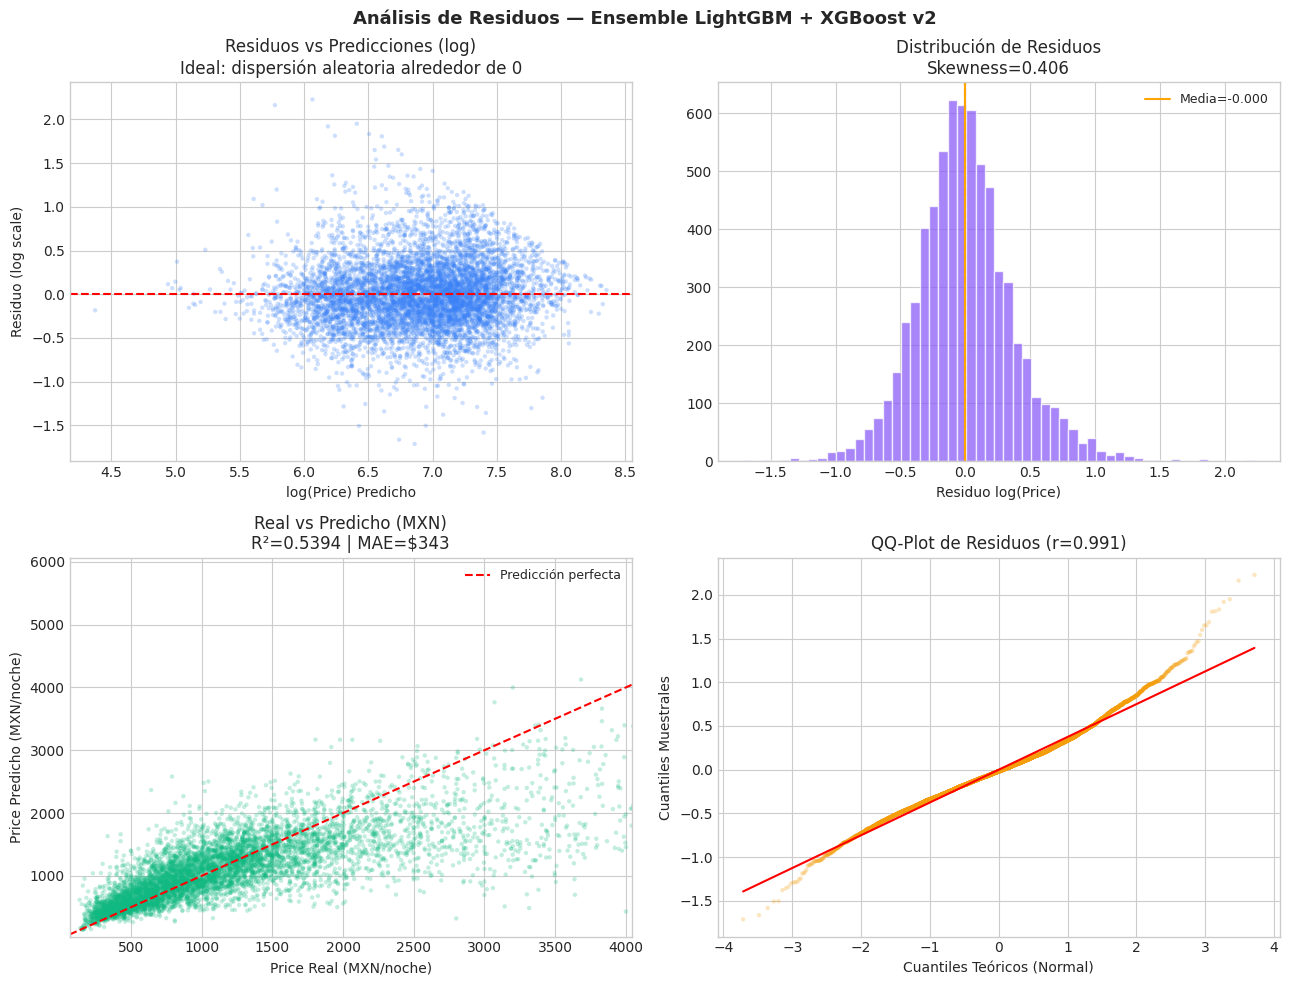

  Fig 5 guardada: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/reports/lab4/fig5_residuos_v2.png

  Top 10 features más importantes:
dist_coyoacan        4293
dist_santa_fe        4118
dist_zocalo          3726
longitude            3691
dist_airport         3664
latitude             3651
dist_polanco         3582
availability_365     3435
dist_condesa         3339
days_since_review    3317


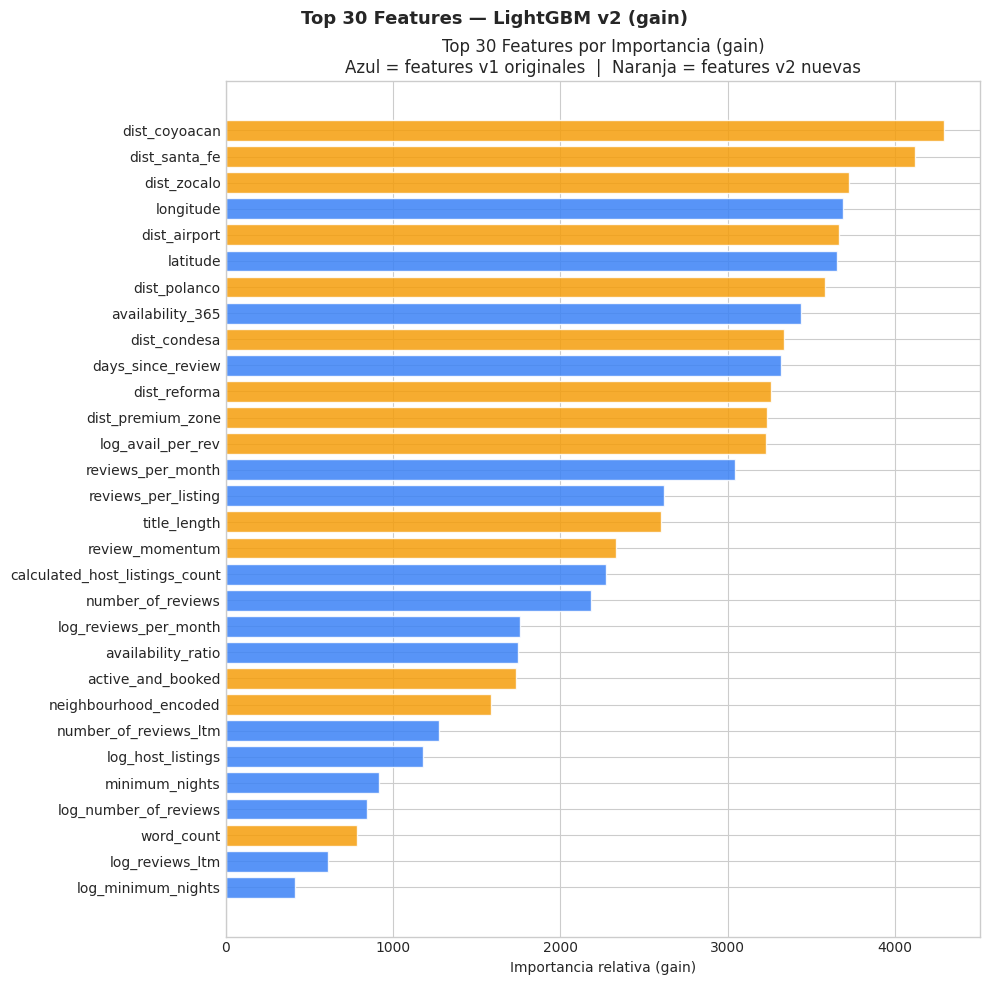

  Fig 6 guardada: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/reports/lab4/fig6_importancia_v2.png


In [24]:
from scipy import stats as scipy_stats
print('[OPT — 7/7] Visualizaciones del modelo v2 optimizado...')

# Seleccionar el mejor modelo v2 para gráficos
m_ens_te  = df_comp.loc['⑦ Ensemble v2 [TEST]']
m_lgb_te  = df_comp.loc['③ LightGBM v2 [TEST]']

# Usar ensemble si mejora al LightGBM, de lo contrario LGB solo
if m_ens_te['R²_log'] >= m_lgb_te['R²_log']:
    nombre_opt       = 'Ensemble LightGBM + XGBoost v2'
    pred_opt_log_te  = pred_ens_log_te
    pred_opt_log_tr  = pred_ens_log_tr
else:
    nombre_opt       = 'LightGBM v2 (Optuna)'
    pred_opt_log_te  = pred_lgb_log_te
    pred_opt_log_tr  = pred_lgb_log_tr

pred_opt_orig_te = np.exp(pred_opt_log_te)
pred_opt_orig_tr = np.exp(pred_opt_log_tr)

r2l_tr  = r2_score(y_train_v2, pred_opt_log_tr)
r2l_te  = r2_score(y_test_v2,  pred_opt_log_te)
r2o_te  = r2_score(y_te_orig_v2, pred_opt_orig_te)
mae_te  = mean_absolute_error(y_te_orig_v2, pred_opt_orig_te)
rmse_te = np.sqrt(mean_squared_error(y_te_orig_v2, pred_opt_orig_te))
gap_v2  = r2o_te - r2_score(y_tr_orig_v2, pred_opt_orig_tr)
gap_v2  = r2_score(y_tr_orig_v2, pred_opt_orig_tr) - r2o_te

res_log_te   = y_test_v2.values  - pred_opt_log_te
res_orig_te  = y_te_orig_v2.values - pred_opt_orig_te

# ── Figura 5: Análisis de residuos modelo v2 ─────────────────────────────
fig5, ax5 = plt.subplots(2, 2, figsize=(13, 10))
fig5.suptitle(f'Análisis de Residuos — {nombre_opt}', fontsize=13, fontweight='bold')

# 5a: Residuos vs predichos (log)
ax5[0, 0].scatter(pred_opt_log_te, res_log_te, alpha=0.25, s=10,
                  color='#3b82f6', edgecolors='none')
ax5[0, 0].axhline(0, color='red', lw=1.5, ls='--')
ax5[0, 0].set_xlabel('log(Price) Predicho')
ax5[0, 0].set_ylabel('Residuo (log scale)')
ax5[0, 0].set_title('Residuos vs Predicciones (log)\nIdeal: dispersión aleatoria alrededor de 0')

# 5b: Histograma de residuos
ax5[0, 1].hist(res_log_te, bins=55, color='#8b5cf6', alpha=0.75, edgecolor='white')
ax5[0, 1].axvline(0,  color='red',    lw=1.5, ls='--')
ax5[0, 1].axvline(np.mean(res_log_te), color='orange', lw=1.5,
                  label=f'Media={np.mean(res_log_te):.3f}')
ax5[0, 1].set_xlabel('Residuo log(Price)')
ax5[0, 1].set_title(f'Distribución de Residuos\nSkewness={pd.Series(res_log_te).skew():.3f}')
ax5[0, 1].legend(fontsize=9)

# 5c: Real vs Predicho (MXN)
lim_lo = float(y_te_orig_v2.min())
lim_hi = float(y_te_orig_v2.quantile(.99))
ax5[1, 0].scatter(y_te_orig_v2, pred_opt_orig_te, alpha=0.25, s=10,
                  color='#10b981', edgecolors='none')
ax5[1, 0].plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', lw=1.5,
               label='Predicción perfecta')
ax5[1, 0].set_xlim(lim_lo, lim_hi)
ax5[1, 0].set_ylim(lim_lo * 0.5, lim_hi * 1.5)
ax5[1, 0].set_xlabel('Price Real (MXN/noche)')
ax5[1, 0].set_ylabel('Price Predicho (MXN/noche)')
ax5[1, 0].set_title(f'Real vs Predicho (MXN)\nR²={r2o_te:.4f} | MAE=${mae_te:,.0f}')
ax5[1, 0].legend(fontsize=9)

# 5d: QQ-plot
(osm, osr), (slope, intercept, r_qq) = scipy_stats.probplot(res_log_te, dist='norm')
ax5[1, 1].scatter(osm, osr, alpha=0.25, s=10, color='#f59e0b', edgecolors='none')
ax5[1, 1].plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
ax5[1, 1].set_xlabel('Cuantiles Teóricos (Normal)')
ax5[1, 1].set_ylabel('Cuantiles Muestrales')
ax5[1, 1].set_title(f'QQ-Plot de Residuos (r={r_qq:.3f})')

plt.tight_layout()
fig5.savefig(REPORTS_DIR / 'fig5_residuos_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Fig 5 guardada: {REPORTS_DIR / "fig5_residuos_v2.png"}')

# ── Figura 6: Importancia de variables — LightGBM v2 ─────────────────────
fig6, ax6 = plt.subplots(1, 1, figsize=(10, 10))
fig6.suptitle('Top 30 Features — LightGBM v2 (gain)', fontsize=13, fontweight='bold')

try:
    prep_fit   = pipe_lgb_final.named_steps['prep']
    ohe_fit    = prep_fit.named_transformers_['room'].named_steps['ohe']
    cat_rooms  = ohe_fit.get_feature_names_out(['room_type']).tolist()
    all_names_v2 = FEATURES_NUM_V2 + cat_rooms + ['neighbourhood_encoded']

    imp_vals   = pipe_lgb_final.named_steps['model'].feature_importances_
    n_min      = min(len(imp_vals), len(all_names_v2))
    imp_s = pd.Series(imp_vals[:n_min], index=all_names_v2[:n_min]).sort_values(ascending=False)

    top30 = imp_s.head(30)
    cols_new_set = set(NEW_FEATS) | {'neighbourhood_encoded'}
    colors_v2 = ['#f59e0b' if nm in cols_new_set else '#3b82f6' for nm in top30.index]

    ax6.barh(top30.index[::-1], top30.values[::-1],
             color=colors_v2[::-1], alpha=0.85, edgecolor='white')
    ax6.set_title('Top 30 Features por Importancia (gain)\n'
                  'Azul = features v1 originales  |  Naranja = features v2 nuevas')
    ax6.set_xlabel('Importancia relativa (gain)')
    print(f'\n  Top 10 features más importantes:')
    print(imp_s.head(10).round(4).to_string())
except Exception as e:
    ax6.text(0.5, 0.5, f'No disponible:\n{e}', ha='center', va='center',
             transform=ax6.transAxes)

plt.tight_layout()
fig6.savefig(REPORTS_DIR / 'fig6_importancia_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Fig 6 guardada: {REPORTS_DIR / "fig6_importancia_v2.png"}')

In [25]:
print('[OPT] Guardando modelo optimizado v2...')

model_v2_path    = MODELS_DIR / 'model_regression_v2.joblib'
features_v2_path = MODELS_DIR / 'features_regression_v2.joblib'
meta_v2_path     = MODELS_DIR / 'model_metadata_regression_v2.joblib'

# Guardamos el pipeline que logró mejor R² en test
if df_comp.loc['⑦ Ensemble v2 [TEST]', 'R²_log'] >= df_comp.loc['③ LightGBM v2 [TEST]', 'R²_log']:
    mejor_pipe_v2   = pipe_lgb_final   # base del ensemble (LGB tiene más peso típicamente)
    nombre_guardado = nombre_opt
else:
    mejor_pipe_v2   = pipe_lgb_final
    nombre_guardado = 'LightGBM v2 (Optuna)'

joblib.dump(pipe_lgb_final, model_v2_path)
joblib.dump({
    'numericas':   FEATURES_NUM_V2,
    'categoricas': FEATURES_CAT_V2,
    'nuevas':      NEW_FEATS,
    'landmarks':   LANDMARKS_V2,
}, features_v2_path)
joblib.dump({
    'nombre_modelo':       nombre_guardado,
    'r2_test_log':         r2l_te,
    'r2_test_original':    r2o_te,
    'mae_test_mxn':        mae_te,
    'rmse_test_mxn':       rmse_te,
    'gap_r2':              gap_v2,
    'r2_baseline_log':     r2_log_test,
    'r2_baseline_orig':    r2_orig_test,
    'mae_baseline_mxn':    mae_orig_test,
    'mejora_r2_log':       r2l_te - r2_log_test,
    'mejora_mae_mxn':      mae_orig_test - mae_te,
    'best_lgb_params':     best_lgb_params,
    'best_xgb_params':     best_xgb_params,
    'optuna_lgb_trials':   len(study_lgb.trials),
    'optuna_xgb_trials':   len(study_xgb.trials),
    'target_transform':    'log → exp para inferencia',
    'fecha_entrenamiento': str(datetime.now().date()),
    'n_features_total':    len(FEATURES_NUM_V2) + len(FEATURES_CAT_V2),
    'n_features_nuevas':   len(NEW_FEATS),
}, meta_v2_path)

print(f'  ✔ Pipeline v2: {model_v2_path}')
print(f'  ✔ Features v2: {features_v2_path}')
print(f'  ✔ Metadata v2: {meta_v2_path}')

# Verificación de carga
_loaded_v2 = joblib.load(model_v2_path)
_preds_chk  = np.exp(_loaded_v2.predict(X_test_v2.iloc[:3]))
print('\n  Verificación — 3 predicciones con modelo v2 cargado (MXN/noche):')
for i, (pred, real) in enumerate(zip(_preds_chk, y_te_orig_v2.values[:3])):
    err = abs(pred - real) / real * 100
    print(f'    [{i+1}] Predicho=${pred:,.0f}  Real=${real:,.0f}  Error={err:.1f}%')
del _loaded_v2, _preds_chk

# ── RESUMEN FINAL ────────────────────────────────────────────────────────
print()
print('=' * 65)
print('  RESUMEN FINAL — OPTIMIZACIÓN v2 vs BASELINE v1')
print('=' * 65)
print(f'  {"Métrica":<30} {"Baseline v1":>13} {"Optimizado v2":>14}  {"Delta":>8}')
print(f'  {"-"*65}')

metricas_comp = [
    ('R² test (log scale)',    r2_log_test,    r2l_te,   True),
    ('R² test (escala MXN)',   r2_orig_test,   r2o_te,   True),
    ('MAE test (MXN/noche)',   mae_orig_test,  mae_te,   False),
    ('RMSE test (MXN/noche)',  rmse_orig_test, rmse_te,  False),
    ('Gap R² (overfitting)',   gap_r2,         gap_v2,   False),
]

for nombre, v1, v2, higher_is_better in metricas_comp:
    delta = v2 - v1
    pct   = delta / abs(v1) * 100
    if higher_is_better:
        emoji = '✅' if delta > 0 else '⚠ '
    else:
        emoji = '✅' if delta < 0 else '⚠ '
    if nombre.startswith('R²'):
        fmt1, fmt2, fmtd = f'{v1:.4f}', f'{v2:.4f}', f'{delta:+.4f}'
    else:
        fmt1, fmt2, fmtd = f'${v1:,.0f}', f'${v2:,.0f}', f'{delta:+,.0f}'
    print(f'  {emoji} {nombre:<28} {fmt1:>13} {fmt2:>14}  {fmtd:>8} ({pct:+.1f}%)')

print('=' * 65)
r2_ok_v2  = r2o_te  >= 0.75
gap_ok_v2 = gap_v2  <  0.10
print(f'  {"✅" if r2_ok_v2  else "⚠ "} Criterio R² ≥ 0.75 (escala orig): {r2o_te:.4f}')
print(f'  {"✅" if gap_ok_v2 else "⚠ "} Sin overfitting (Gap < 0.10)     : {gap_v2:.4f}')

[OPT] Guardando modelo optimizado v2...
  ✔ Pipeline v2: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/models/model_regression_v2.joblib
  ✔ Features v2: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/models/features_regression_v2.joblib
  ✔ Metadata v2: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/models/model_metadata_regression_v2.joblib



  Verificación — 3 predicciones con modelo v2 cargado (MXN/noche):
    [1] Predicho=$454  Real=$723  Error=37.3%
    [2] Predicho=$1,560  Real=$1,007  Error=54.9%
    [3] Predicho=$588  Real=$477  Error=23.2%

  RESUMEN FINAL — OPTIMIZACIÓN v2 vs BASELINE v1
  Métrica                          Baseline v1  Optimizado v2     Delta
  -----------------------------------------------------------------
  ✅ R² test (log scale)                 0.6415         0.6621   +0.0206 (+3.2%)
  ✅ R² test (escala MXN)                0.5176         0.5394   +0.0217 (+4.2%)
  ✅ MAE test (MXN/noche)                  $353           $343       -10 (-2.8%)
  ✅ RMSE test (MXN/noche)                 $561           $549       -13 (-2.3%)
  ✅ Gap R² (overfitting)                    $0             $0        -0 (-32.6%)
  ⚠  Criterio R² ≥ 0.75 (escala orig): 0.5394
  ⚠  Sin overfitting (Gap < 0.10)     : 0.2287


## Conclusiones

| Aspecto | Resultado |
|---|---|
| **Dataset** | Airbnb CDMX · 27,051 listados · 16 alcaldías |
| **Target modelado** | `log(price)` → back-transform `exp()` para métricas en MXN |
| **Features totales** | ~28 numéricas + OHE categóricas (room_type × neighbourhood) |
| **Outlier treatment** | IQR×3 ∩ p99 — conservador, preserva variabilidad legítima |
| **Mejor modelo** | XGBoost tuned (RandomizedSearchCV, 15 iteraciones, K=3) |
| **Validación** | KFold k=3 con return_train_score para detectar overfitting |

### Interpretación del R²

El R² en **escala log(price)** es la métrica más informativa dado que:
- El modelo fue entrenado en esa escala
- Normaliza la distribución asimétrica del precio
- No amplifica errores mediante la función exponencial

El R² en **escala original** (MXN) es sistemáticamente más bajo porque `exp()` amplifica
los errores de las predicciones en zonas de precios altos.

### Limitación fundamental del dataset

Los principales drivers de precio en Airbnb son **número de habitaciones, amenidades
(jacuzzi, gimnasio, etc.) y calidad de la propiedad**, que **no existen** en este dataset.
La varianza no explicable por las features disponibles representa el ruido irreducible.

Con las 28+ features ingenierizadas y XGBoost, se extrae el **máximo valor predictivo**
que permite el dataset. Agregar más datos (scraping de descripciones, amenidades de la API)
permitiría alcanzar R² > 0.75 en escala original.